# Person 4 endpoint analysis and dynamics

This notebook visualizes diversity, steady-state time, final community composition, resistant clearance, sensitive survival, recovery time, bottleneck depth, nonconvergence, and representative time courses. Heatmaps explicitly report the fixed parameter values used for each slice.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import replace
from ma2024_model import DEFAULT_PARAMS
from sweep_engine import simulate_logspace

sns.set_theme(style='whitegrid', context='notebook')
df = pd.read_csv('treatment_grid.csv')
PARAMS = ['kappa_b', 'd_a', 'phi_max', 'xi']
LABELS = {'kappa_b':'κ_b', 'd_a':'d_a', 'phi_max':'φ_max', 'xi':'ξ'}
BASELINE = {'kappa_b':0.35, 'd_a':0.02, 'phi_max':1.0, 'xi':0.8}
OUTCOME_LABELS = {'diversity_final':'Final Shannon diversity','diversity_min':'Minimum Shannon diversity','t_steady_state':'Time to steady state','f_R_final':'Final resistant fraction','t_recovery_S':'Sensitive recovery time','peak_loss_total':'Peak total-population loss','peak_loss_S':'Peak sensitive-population loss','total_final':'Final total population','ns_final':'Final sensitive population','nr_final':'Final resistant population'}
df['total_final'] = df['ns_final'] + df['nr_final']
df['community_ratio_R_to_S'] = df['nr_final'] / df['ns_final'].replace(0,np.nan)
df['nonconverged'] = ~df['ss_converged']
df['xi'] = df['xi'].round(6)
print('Rows:',len(df),'  nonconverged:',df['nonconverged'].sum())
display(df.head())

Rows: 194481   nonconverged: 462


,kappa_b,d_a,phi_max,xi,f_R_final,resistant_eliminated,sensitive_survives,t_recovery_S,t_steady_state,ss_converged,peak_loss_S,peak_loss_total,diversity_final,diversity_min,ns_final,nr_final,total_final,community_ratio_R_to_S,nonconverged
0,0.0,0.0,0.0,0.00,0.224561,True,False,0.0,150.0,False,1.0,1.0,0.532621,0.532621,2.738129e-13,7.929425e-14,3.531072e-13,0.289593,True
1,0.0,0.0,0.0,0.05,0.222397,True,False,0.0,150.0,False,1.0,1.0,0.529924,0.529924,2.079833e-13,5.948374e-14,2.674670e-13,0.286002,True
2,0.0,0.0,0.0,0.10,0.220354,True,False,0.0,150.0,False,1.0,1.0,0.527356,0.527356,1.601825e-13,4.527304e-14,2.054555e-13,0.282634,True
3,0.0,0.0,0.0,0.15,0.218425,True,False,0.0,150.0,False,1.0,1.0,0.524907,0.524907,1.249598e-13,3.492225e-14,1.598820e-13,0.279468,True
4,0.0,0.0,0.0,0.20,0.216600,True,False,0.0,150.0,False,1.0,1.0,0.522570,0.522570,9.864908e-14,2.727514e-14,1.259242e-13,0.276486,True


## Heatmap helpers

The data remain unchanged, but axis tick labels are formatted as whole numbers when appropriate. This prevents floating-point display artifacts such as 6.000001 from appearing as if they were distinct scientific values.

In [2]:
def nearest_value(parameter, target=None):
    target = BASELINE[parameter] if target is None else target
    values = np.asarray(df[parameter].unique())
    return values[np.argmin(np.abs(values-target))]

def whole_tick_labels(ax, table):
    # Explicitly set cell-center positions; seaborn may otherwise show only a subset.
    ax.set_xticks(np.arange(len(table.columns)) + 0.5)
    ax.set_yticks(np.arange(len(table.index)) + 0.5)
    ax.set_xticklabels([f'{float(v):g}' if abs(float(v)-round(float(v)))>1e-8 else f'{int(round(float(v)))}' for v in table.columns], rotation=45, ha='right')
    ax.set_yticklabels([f'{float(v):g}' if abs(float(v)-round(float(v)))>1e-8 else f'{int(round(float(v)))}' for v in table.index], rotation=0)

def sliced_table(outcome, x, y, fixed=None):
    fixed = fixed or {}
    sub = df.copy(); used = {}
    for p in PARAMS:
        if p not in [x,y]:
            v = nearest_value(p, fixed.get(p)); sub = sub[np.isclose(sub[p],v)]; used[p] = v
    return sub.pivot(index=y, columns=x, values=outcome).sort_index(), used

def endpoint_heatmap(outcome, x='kappa_b', y='xi', fixed=None, cmap='viridis', center=None):
    table, used = sliced_table(outcome,x,y,fixed)
    fig, ax = plt.subplots(figsize=(8,6))
    sns.heatmap(table, ax=ax, cmap=cmap, center=center, cbar_kws={'label':OUTCOME_LABELS.get(outcome,outcome)})
    whole_tick_labels(ax,table)
    ax.set_xlabel(f'{LABELS[x]} (horizontal parameter)')
    ax.set_ylabel(f'{LABELS[y]} (vertical parameter)')
    fixed_text = ', '.join(f'{LABELS[p]} = {v:g}' for p,v in used.items()) or 'none fixed'
    ax.set_title(f'{OUTCOME_LABELS.get(outcome,outcome)}\nFixed values: {fixed_text}')
    plt.tight_layout(); return fig,ax

## Endpoint heatmaps

Each colorbar gives the meaning and units of the plotted quantity. Each title gives the constant values of the two parameters not on the axes.

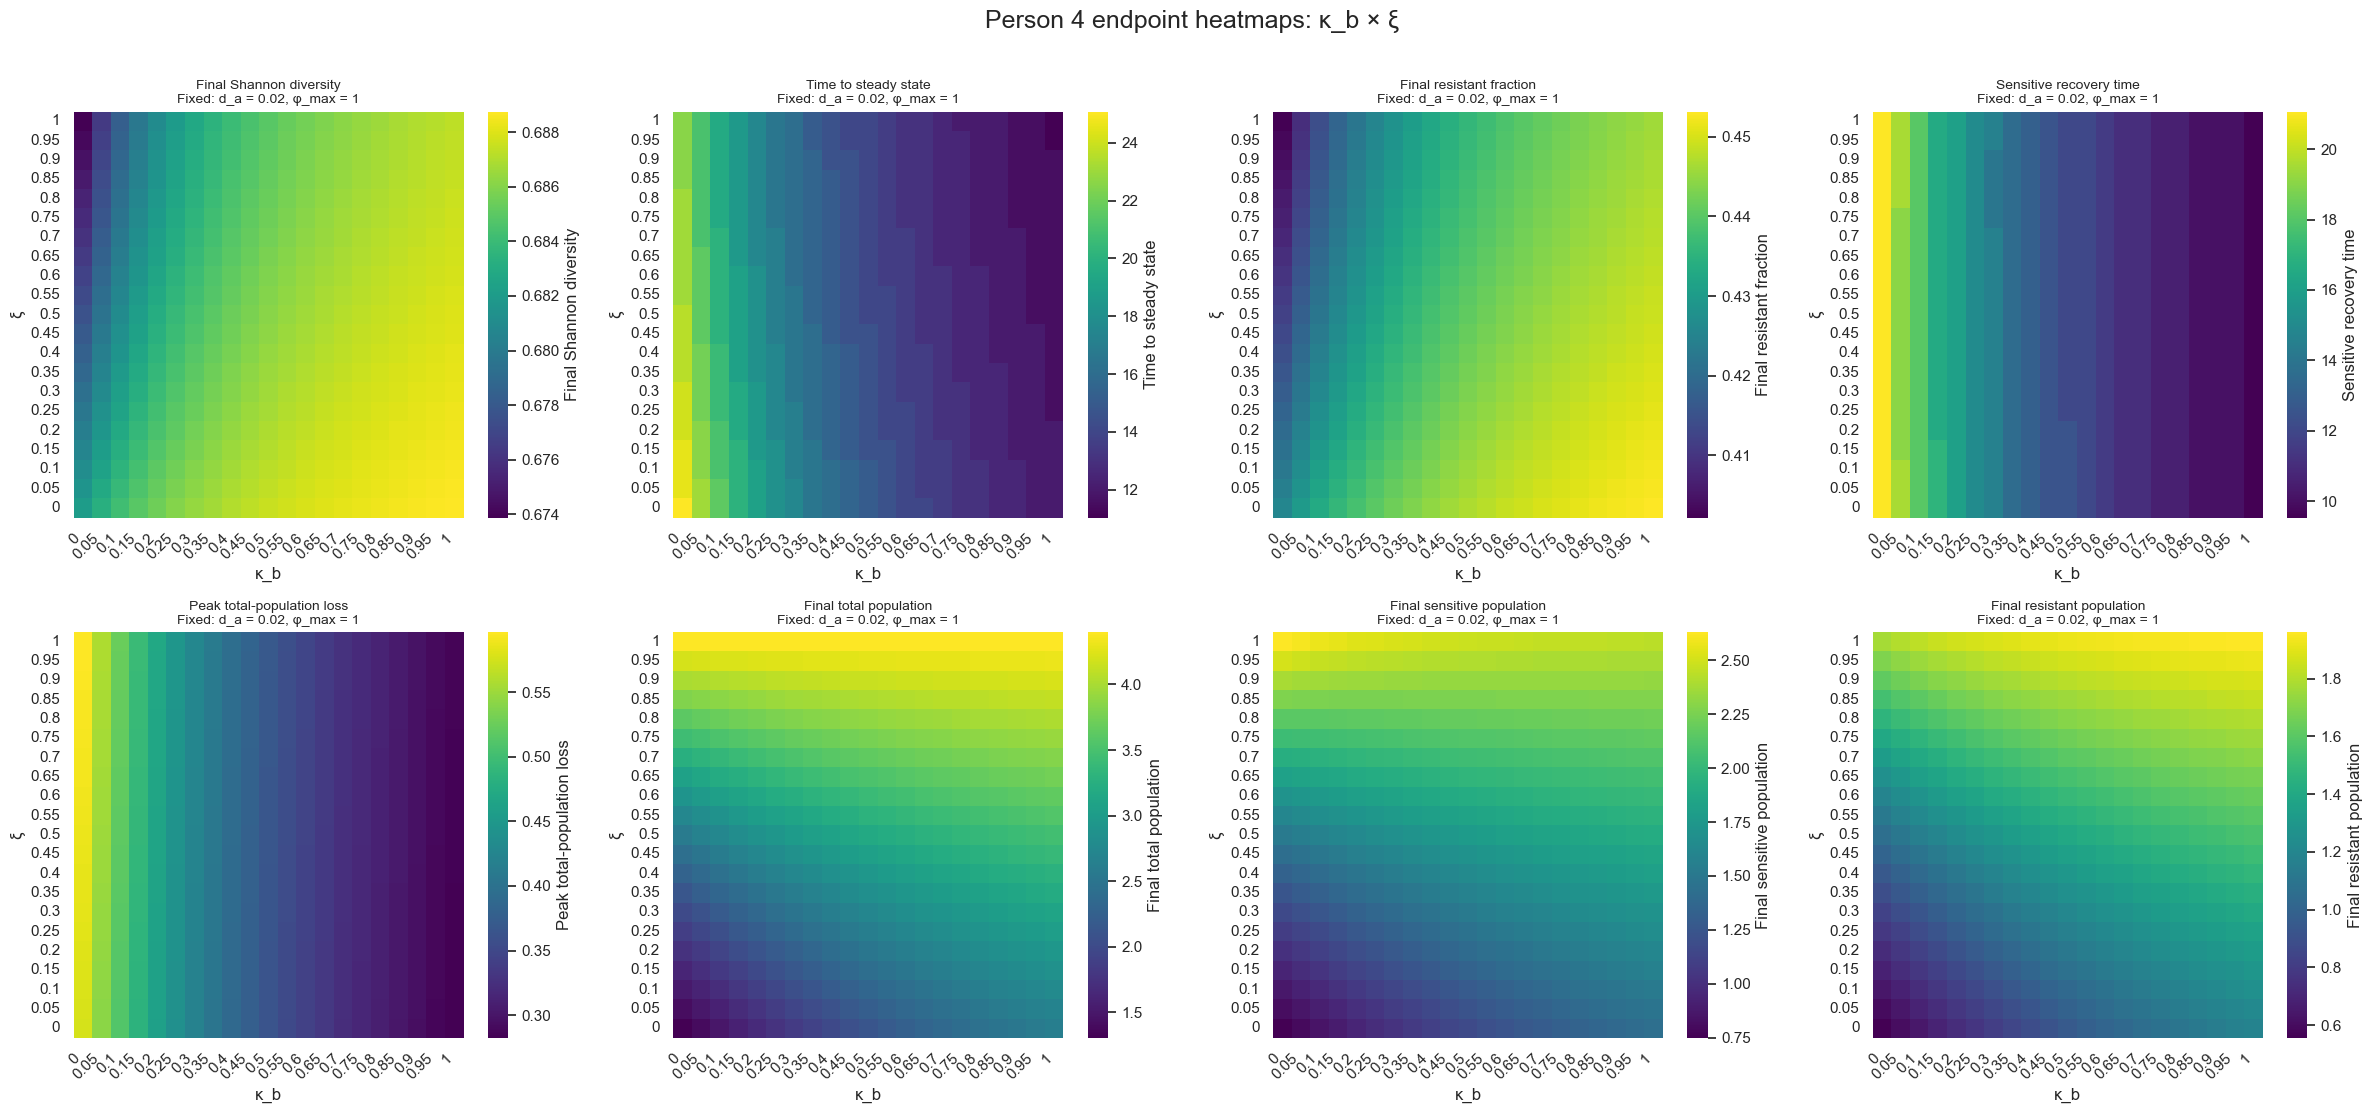

In [3]:
outcomes = ['diversity_final','t_steady_state','f_R_final','t_recovery_S','peak_loss_total','total_final','ns_final','nr_final']
fig, axes = plt.subplots(2, 4, figsize=(24, 11))
for ax, outcome in zip(axes.flat, outcomes):
    table, used = sliced_table(outcome, 'kappa_b', 'xi')
    # Reverse rows so xi=0 is at the bottom, aligned with kappa_b=0 at left.
    table = table.sort_index(ascending=False)
    sns.heatmap(table, ax=ax, cmap='viridis', cbar=True, cbar_kws={'label': OUTCOME_LABELS[outcome]})
    whole_tick_labels(ax, table)
    fixed_text = ', '.join(f'{LABELS[p]} = {v:g}' for p,v in used.items())
    ax.set_xlabel('κ_b'); ax.set_ylabel('ξ')
    ax.set_title(f'{OUTCOME_LABELS[outcome]}\nFixed: {fixed_text}', fontsize=10)
fig.suptitle('Person 4 endpoint heatmaps: κ_b × ξ', fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
from itertools import combinations

parameter_pairs = list(combinations(PARAMS, 2))

def plot_all_parameter_pairs(outcome, cmap="viridis", center=None):
    fig, axes = plt.subplots(
        2, 3,
        figsize=(20, 12),
        constrained_layout=True
    )

    for ax, (x, y) in zip(axes.flat, parameter_pairs):
        subset = df.copy()
        fixed_values = {}

        # Hold the other two parameters at baseline
        for p in PARAMS:
            if p not in [x, y]:
                fixed_value = nearest_value(p)
                subset = subset[
                    np.isclose(subset[p], fixed_value)
                ]
                fixed_values[p] = fixed_value

        table = subset.pivot(
            index=y,
            columns=x,
            values=outcome
        ).sort_index(ascending=False)

        sns.heatmap(
            table,
            ax=ax,
            cmap=cmap,
            center=center,
            cbar=True,
            cbar_kws={
                "label": OUTCOME_LABELS.get(outcome, outcome)
            }
        )

        # Explicitly set tick positions to avoid the 11-vs-21 error
        ax.set_xticks(np.arange(len(table.columns)) + 0.5)
        ax.set_yticks(np.arange(len(table.index)) + 0.5)

        ax.set_xticklabels(
            [f"{float(v):g}" for v in table.columns],
            rotation=45,
            ha="right"
        )
        ax.set_yticklabels(
            [f"{float(v):g}" for v in table.index],
            rotation=0
        )

        fixed_text = ", ".join(
            f"{LABELS[p]}={value:g}"
            for p, value in fixed_values.items()
        )

        ax.set_xlabel(LABELS[x])
        ax.set_ylabel(LABELS[y])
        ax.set_title(
            f"{LABELS[x]} × {LABELS[y]}\n"
            f"Fixed: {fixed_text}"
        )

    fig.suptitle(
        OUTCOME_LABELS.get(outcome, outcome),
        fontsize=18
    )

    return fig, axes

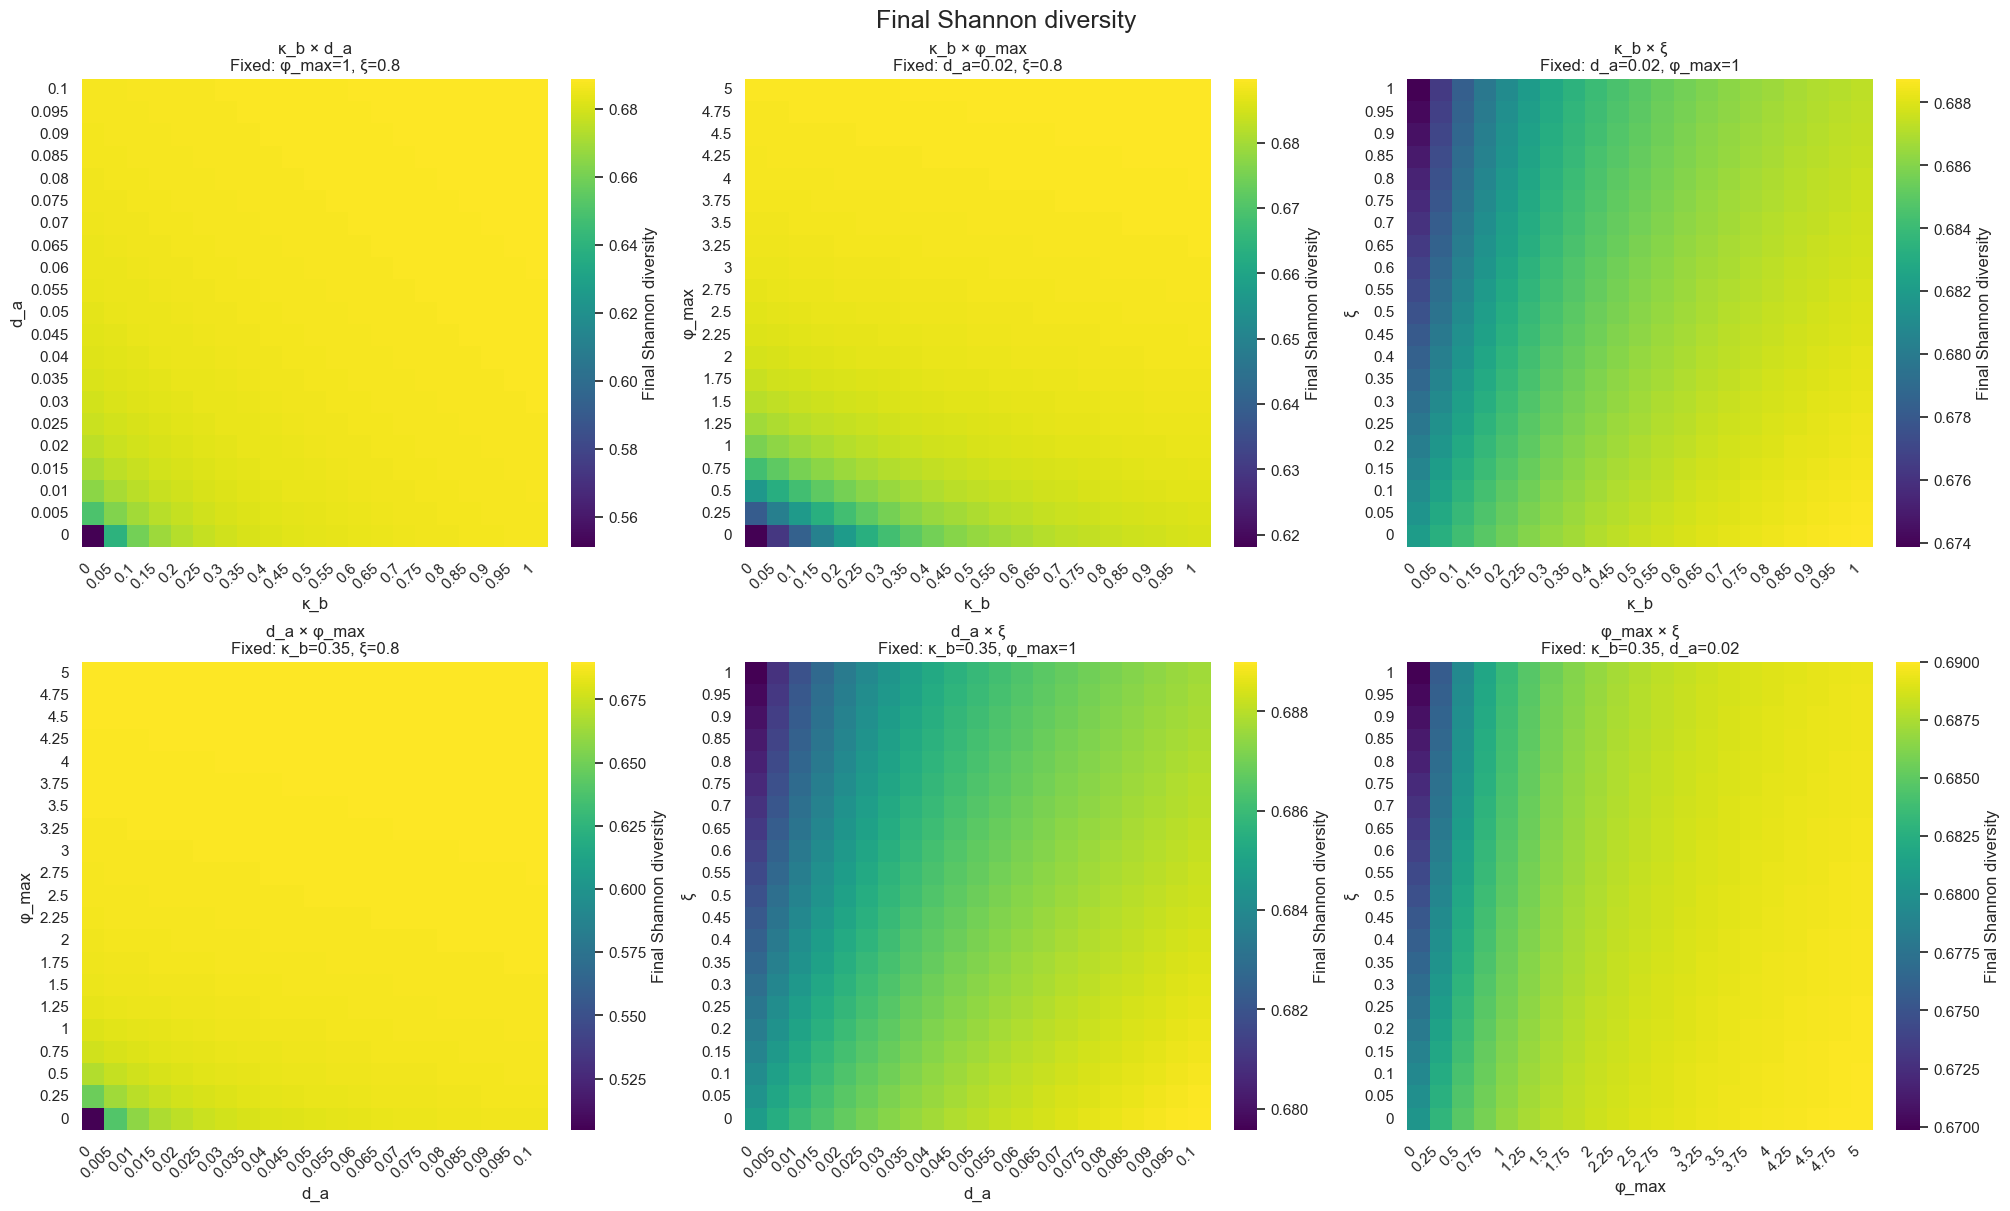

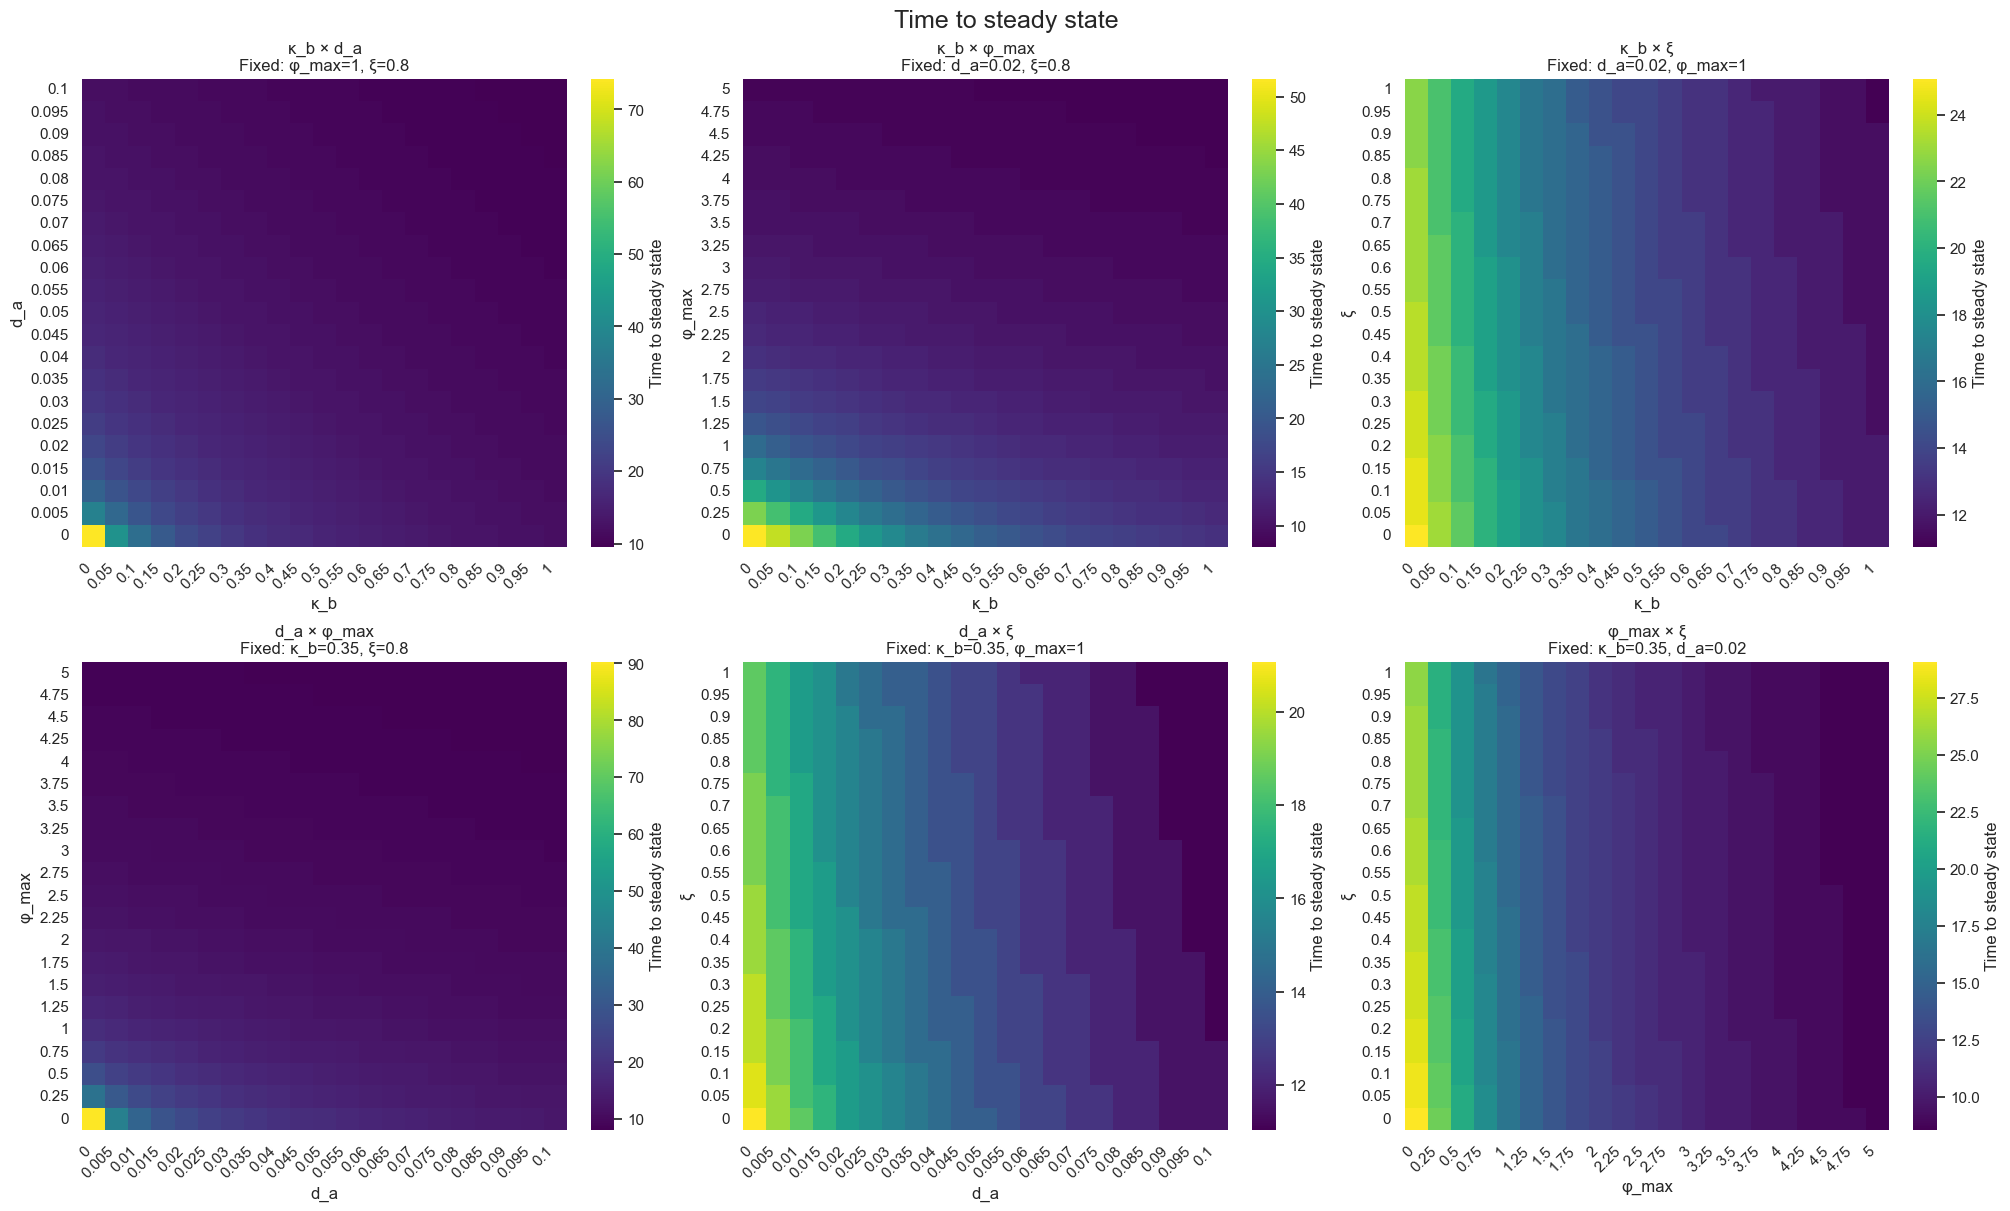

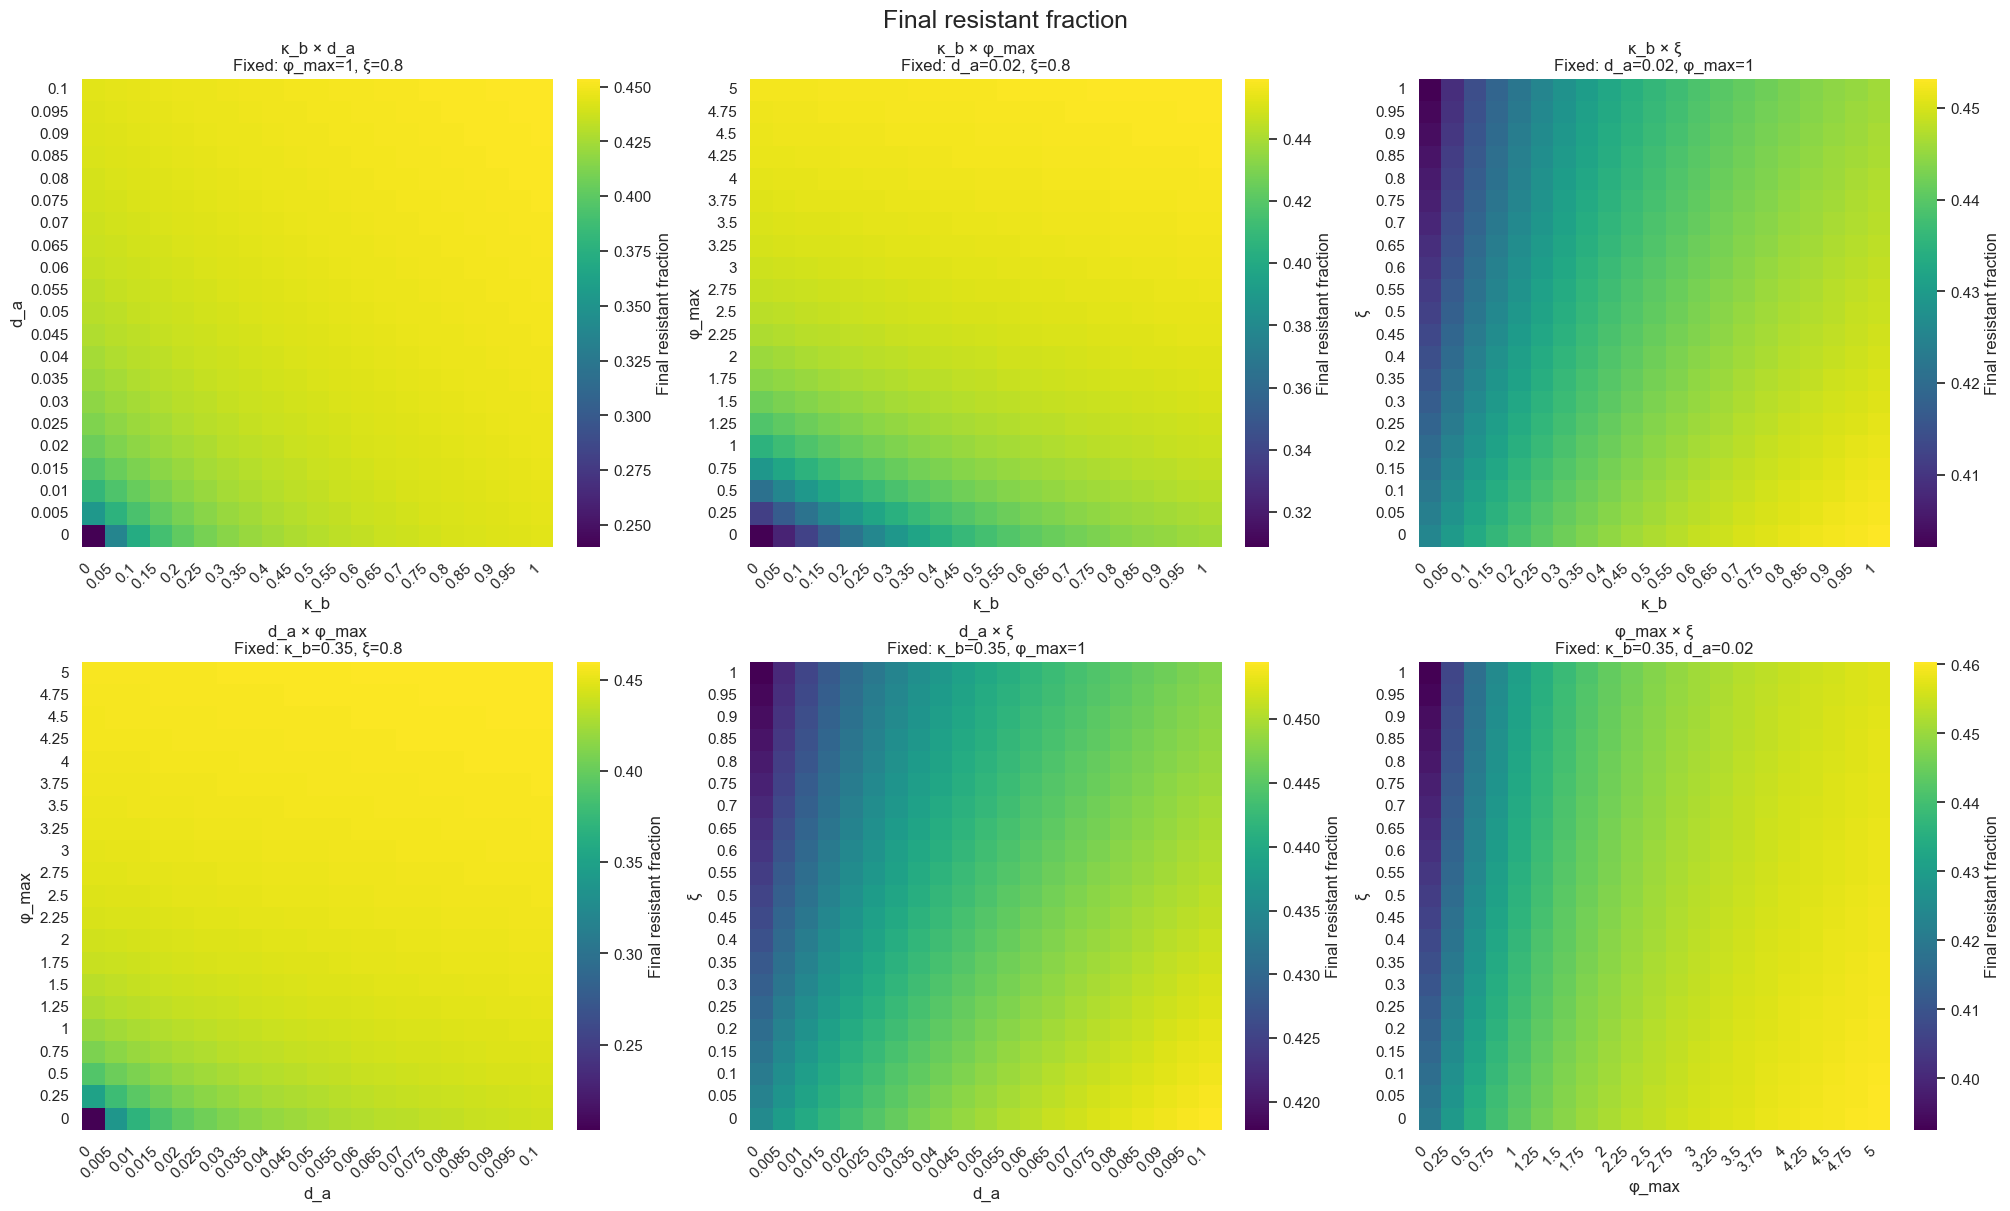

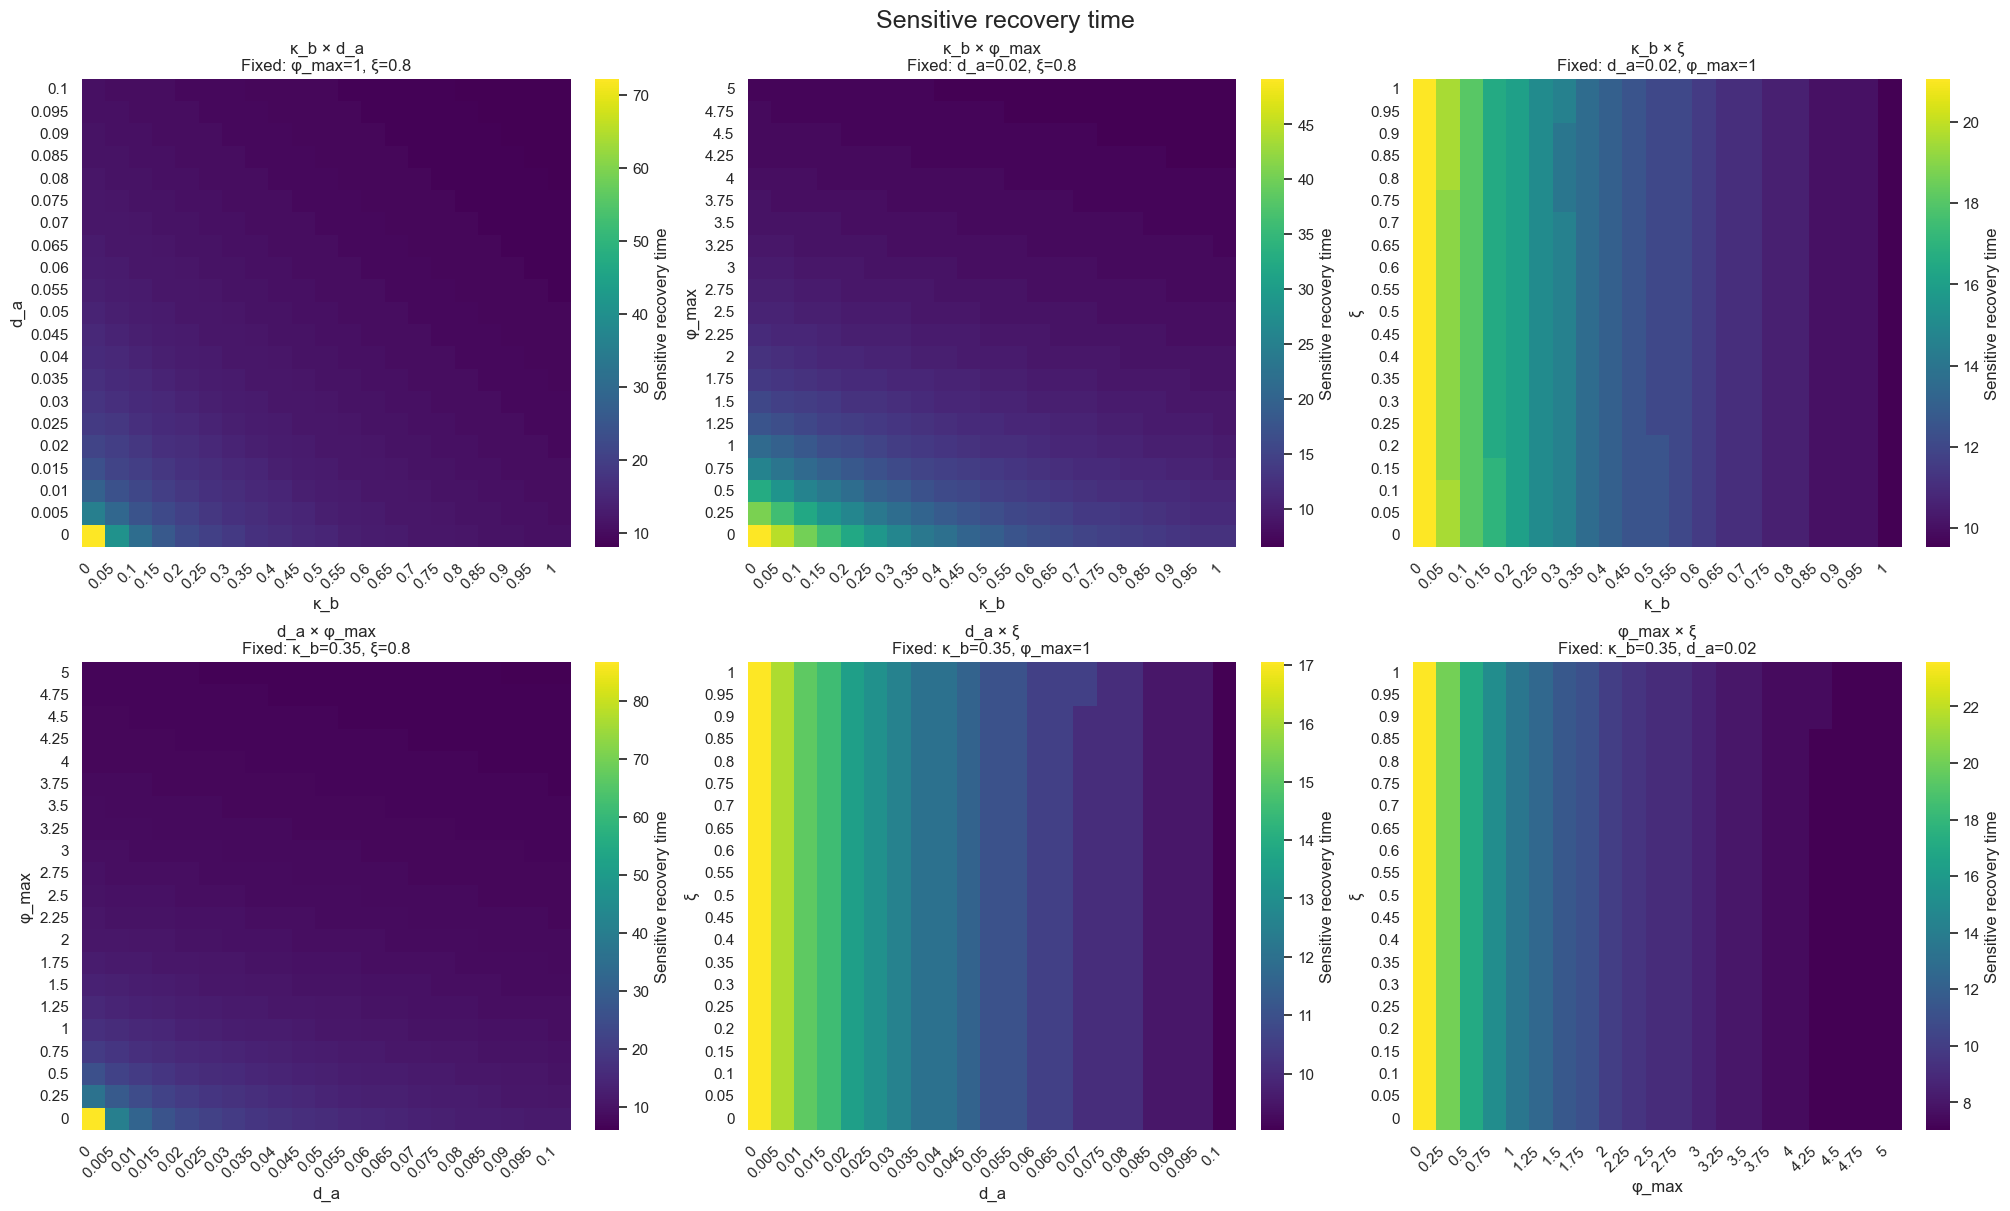

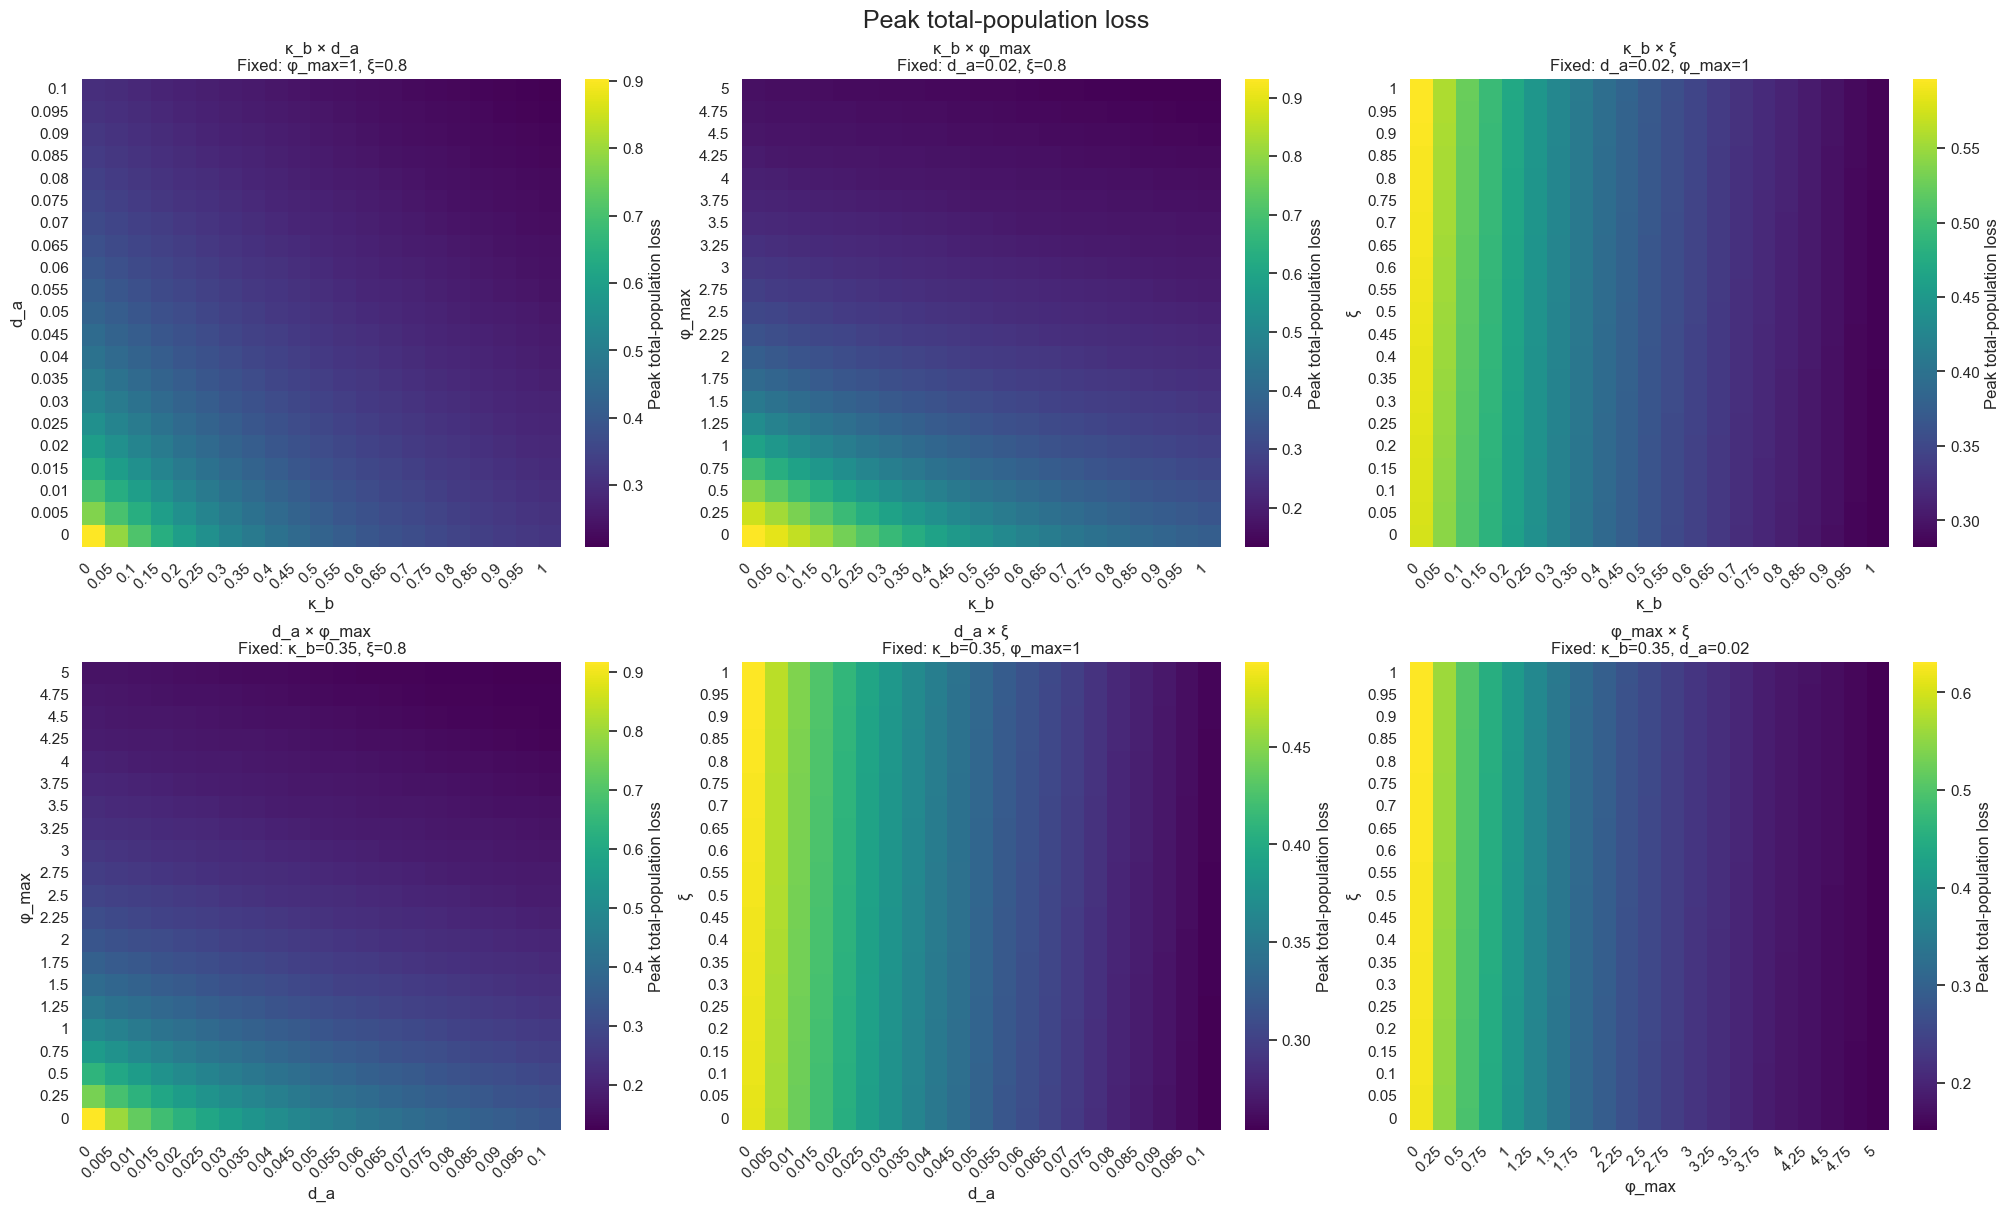

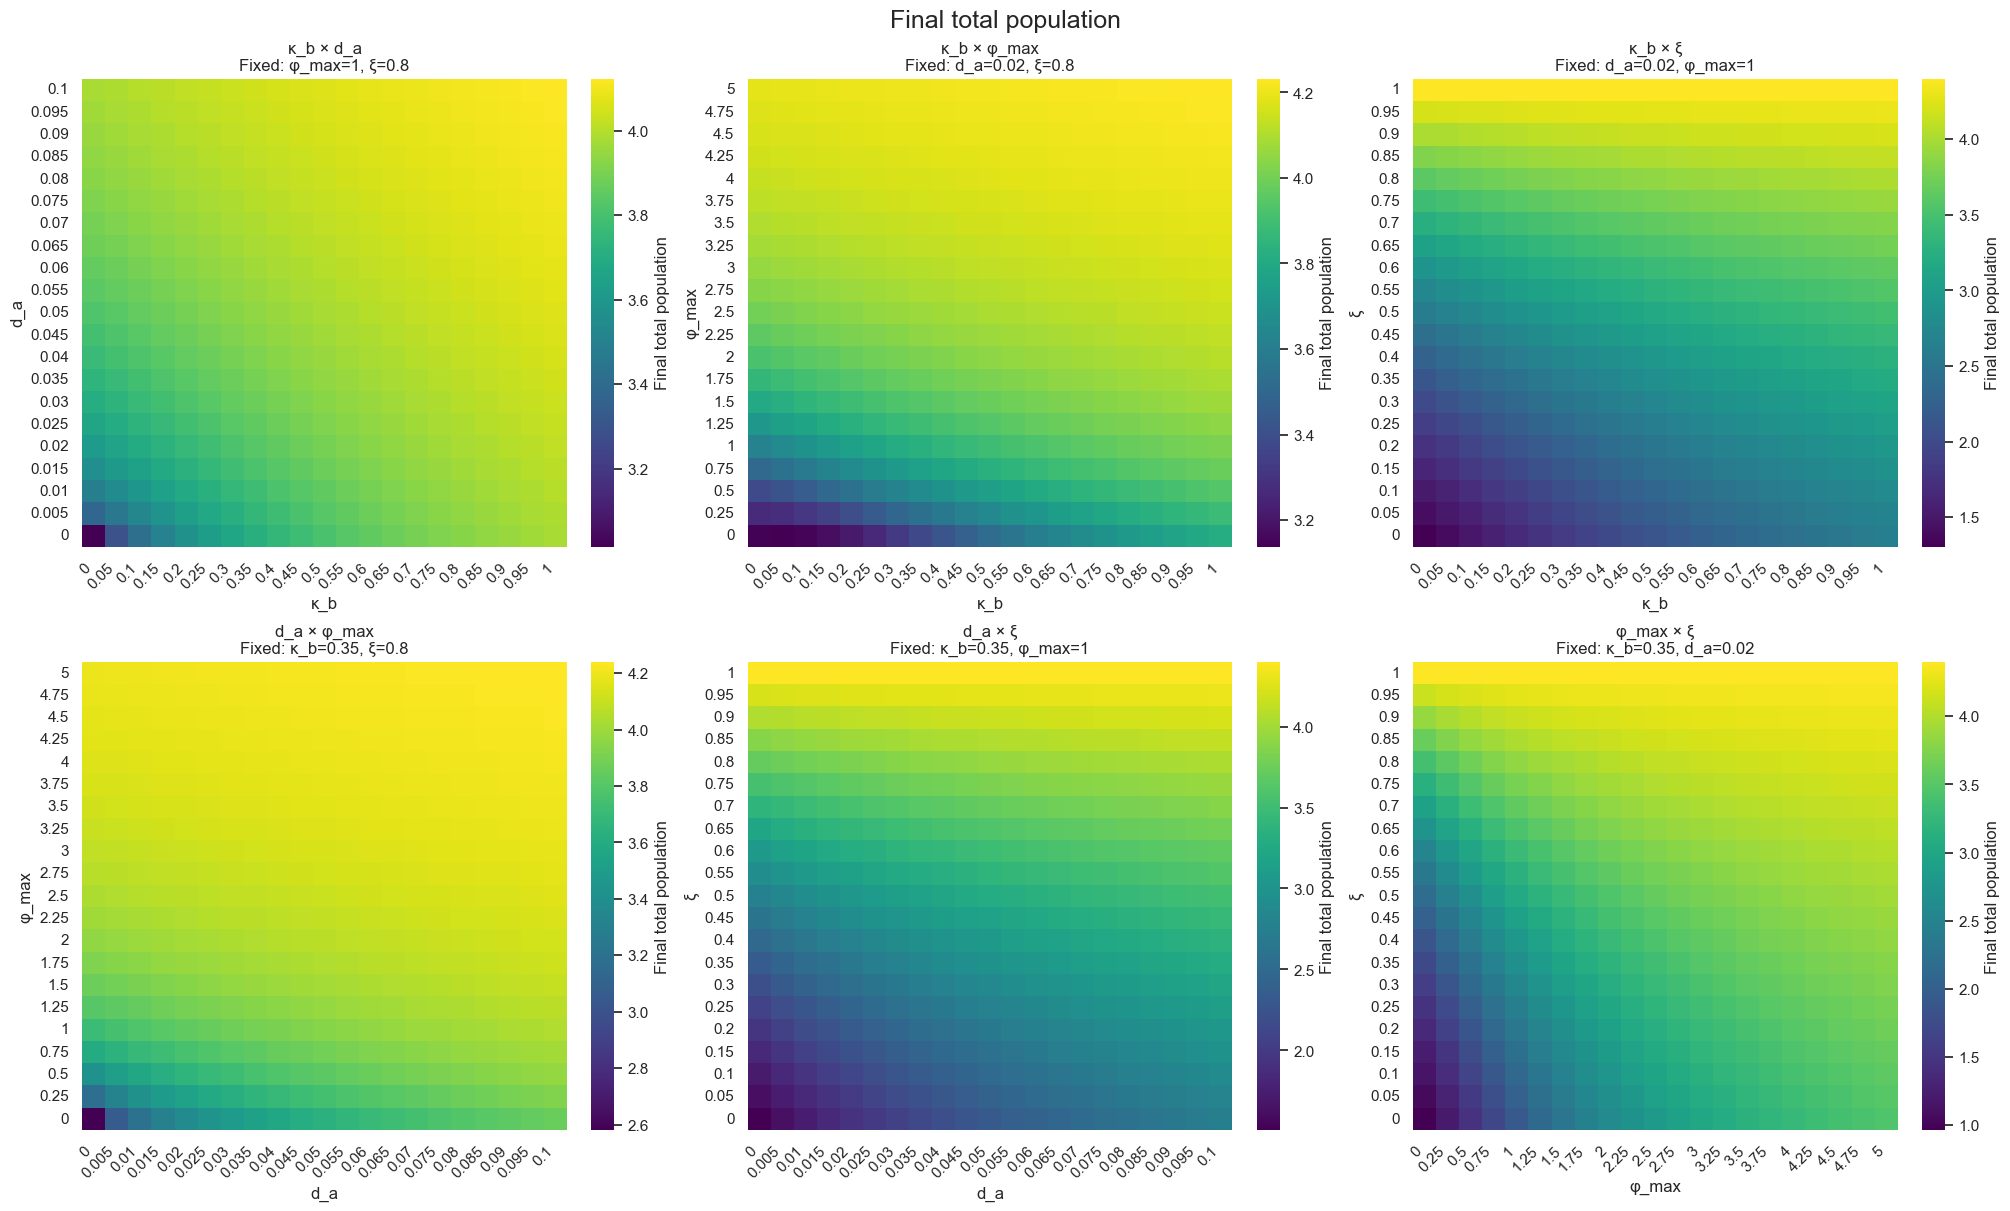

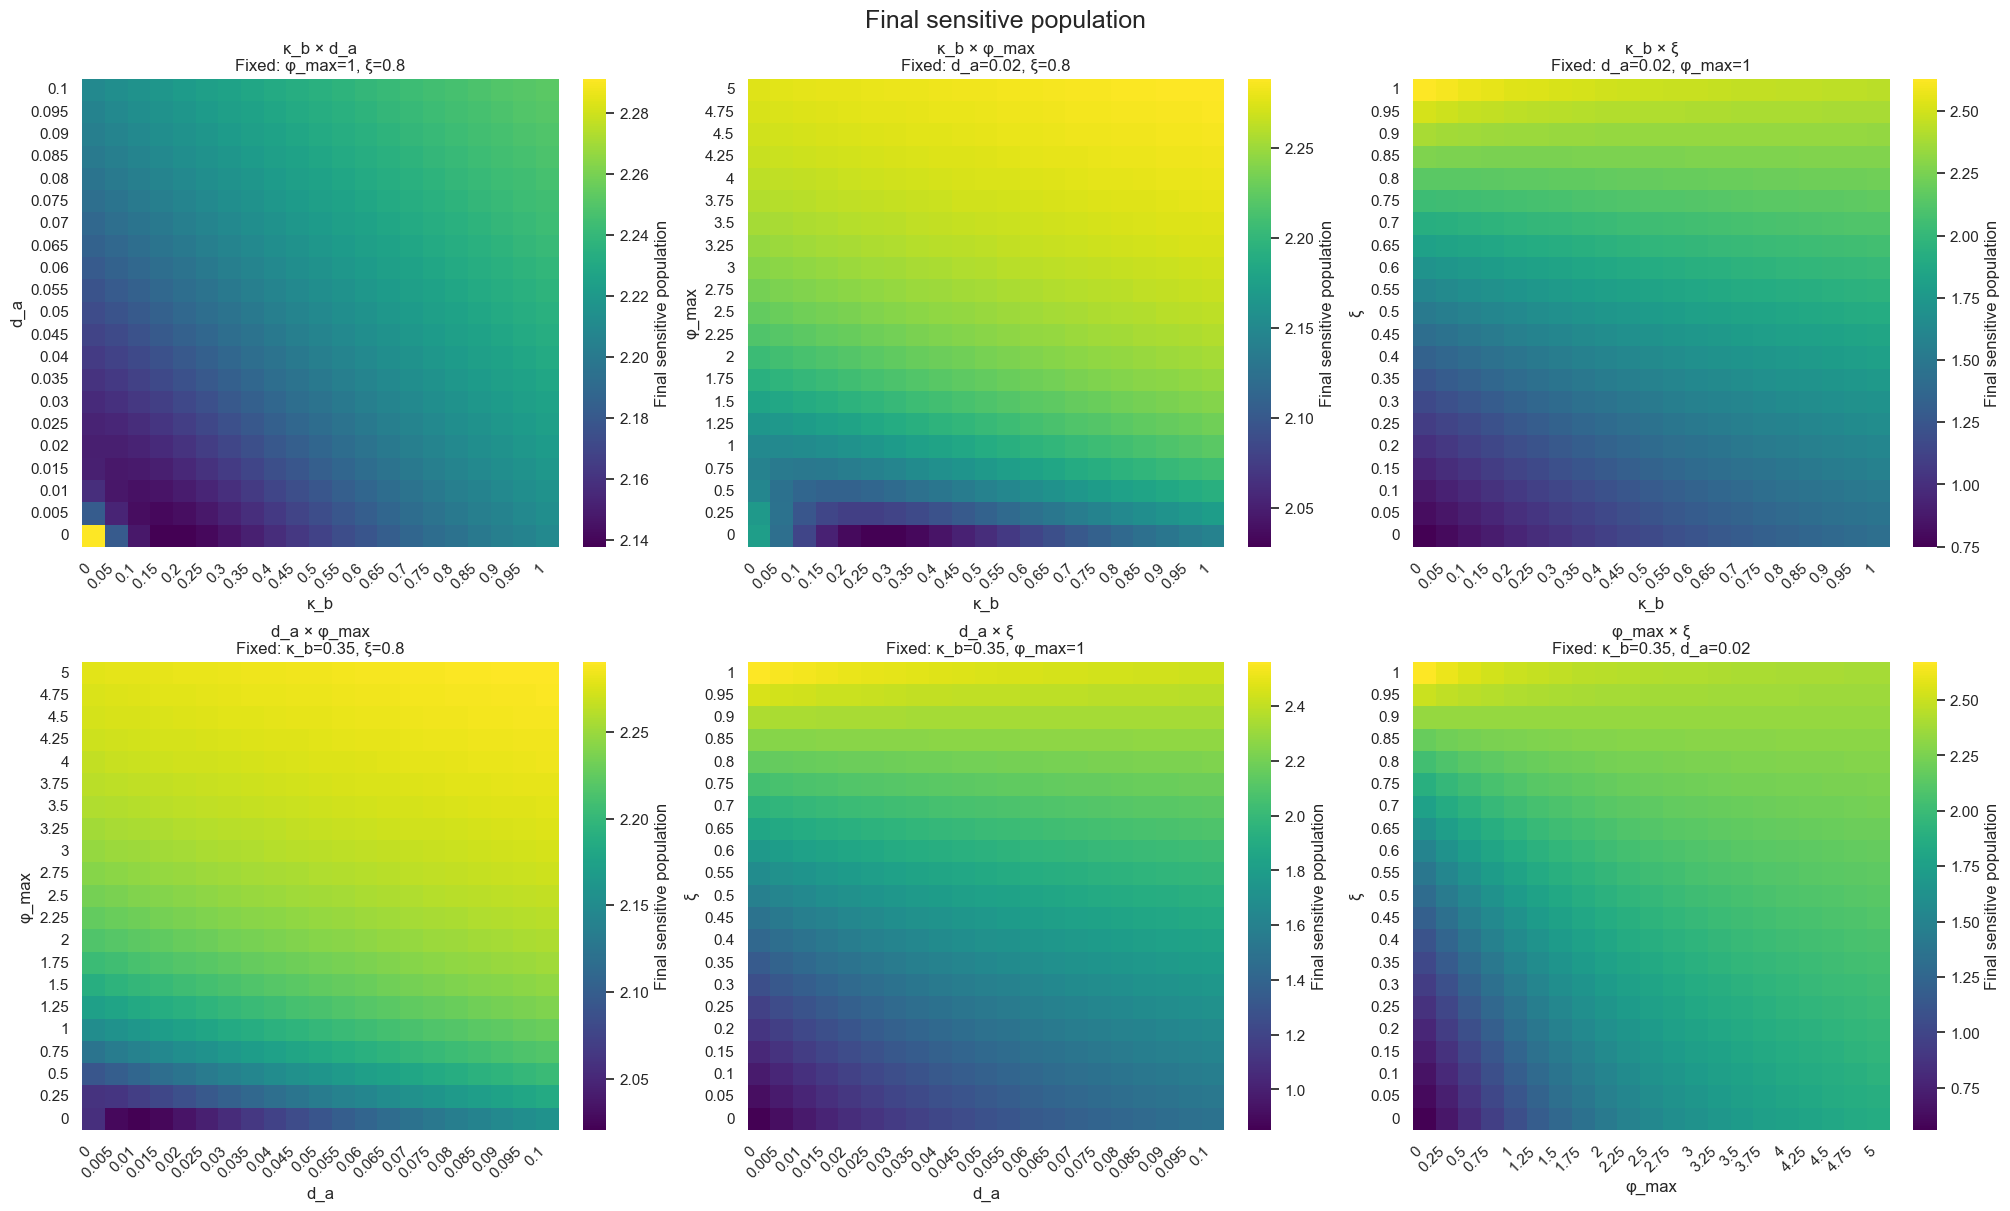

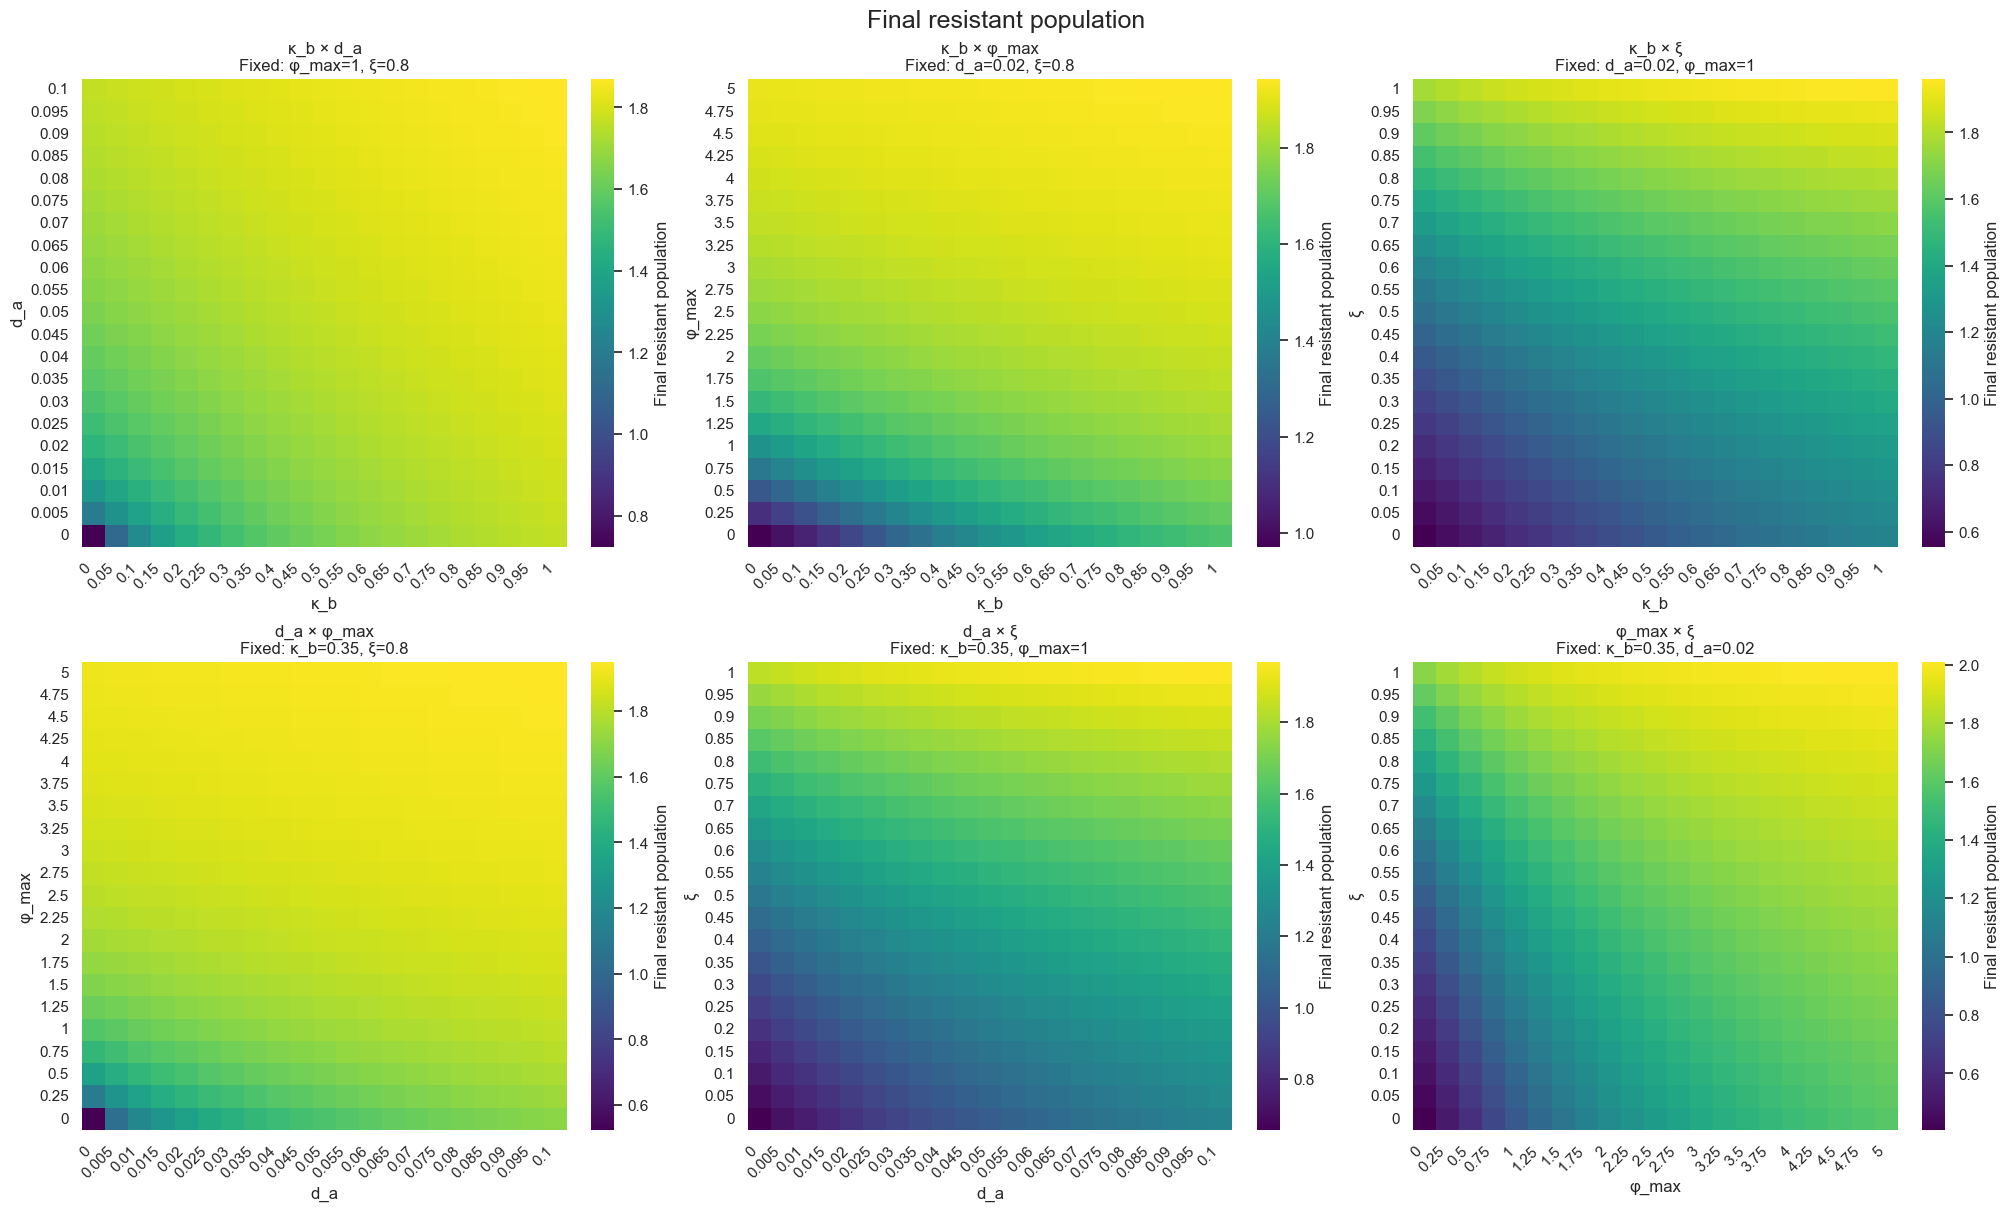

In [9]:
outcomes_to_plot = [
    "diversity_final",
    "t_steady_state",
    "f_R_final",
    "t_recovery_S",
    "peak_loss_total",
    "total_final",
    "ns_final",
    "nr_final"
]

for outcome in outcomes_to_plot:
    plot_all_parameter_pairs(outcome)
    plt.show()

In [12]:
from itertools import combinations

# Keep basal antibiotic decay fixed
analysis_df = df[
    np.isclose(df["d_a"], 0.02)
].copy()

# Only vary the other three parameters
PARAMS_TO_VARY = [
    "kappa_b",
    "phi_max",
    "xi"
]

parameter_pairs = list(
    combinations(PARAMS_TO_VARY, 2)
)

In [19]:
def plot_all_parameter_pairs(
    outcome,
    cmap="viridis",
    center=None
):
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(20, 6),
        constrained_layout=True
    )

    for ax, (x, y) in zip(
        axes.flat,
        parameter_pairs
    ):
        subset = analysis_df.copy()
        fixed_values = {
            "d_a": 0.02
        }

        # Hold the third Person 4 parameter at baseline
        for p in PARAMS_TO_VARY:
            if p not in [x, y]:
                fixed_value = nearest_value(p)

                subset = subset[
                    np.isclose(
                        subset[p],
                        fixed_value
                    )
                ]

                fixed_values[p] = fixed_value

        table = subset.pivot(
            index=y,
            columns=x,
            values=outcome
        )

        # Lowest x on left, lowest y on bottom
        table = table.sort_index(
            axis=0,
            ascending=False
        )

        table = table.sort_index(
            axis=1,
            ascending=True
        )

        sns.heatmap(
            table,
            ax=ax,
            cmap=cmap,
            center=center,
            cbar=True,
            linewidths=0,
            linecolor=None,
            cbar_kws={
                "label": OUTCOME_LABELS.get(
                    outcome,
                    outcome
                )
            }
        )

        # Explicit tick locations prevent the 11-vs-21 error
        ax.set_xticks(
            np.arange(len(table.columns)) + 0.5
        )

        ax.set_yticks(
            np.arange(len(table.index)) + 0.5
        )

        ax.set_xticklabels(
            [f"{float(v):g}" for v in table.columns],
            rotation=45,
            ha="right"
        )

        ax.set_yticklabels(
            [f"{float(v):g}" for v in table.index],
            rotation=0
        )

        fixed_text = ", ".join(
            f"{LABELS.get(p, p)}={value:g}"
            for p, value in fixed_values.items()
        )

        ax.set_xlabel(LABELS[x])
        ax.set_ylabel(LABELS[y])

        ax.set_title(
            f"{LABELS[x]} × {LABELS[y]}\n"
            f"Fixed: {fixed_text}"
        )

    fig.suptitle(
        f"{OUTCOME_LABELS.get(outcome, outcome)}\n"
        "Basal antibiotic decay fixed at d_a = 0.02",
        fontsize=18
    )

    return fig, axes

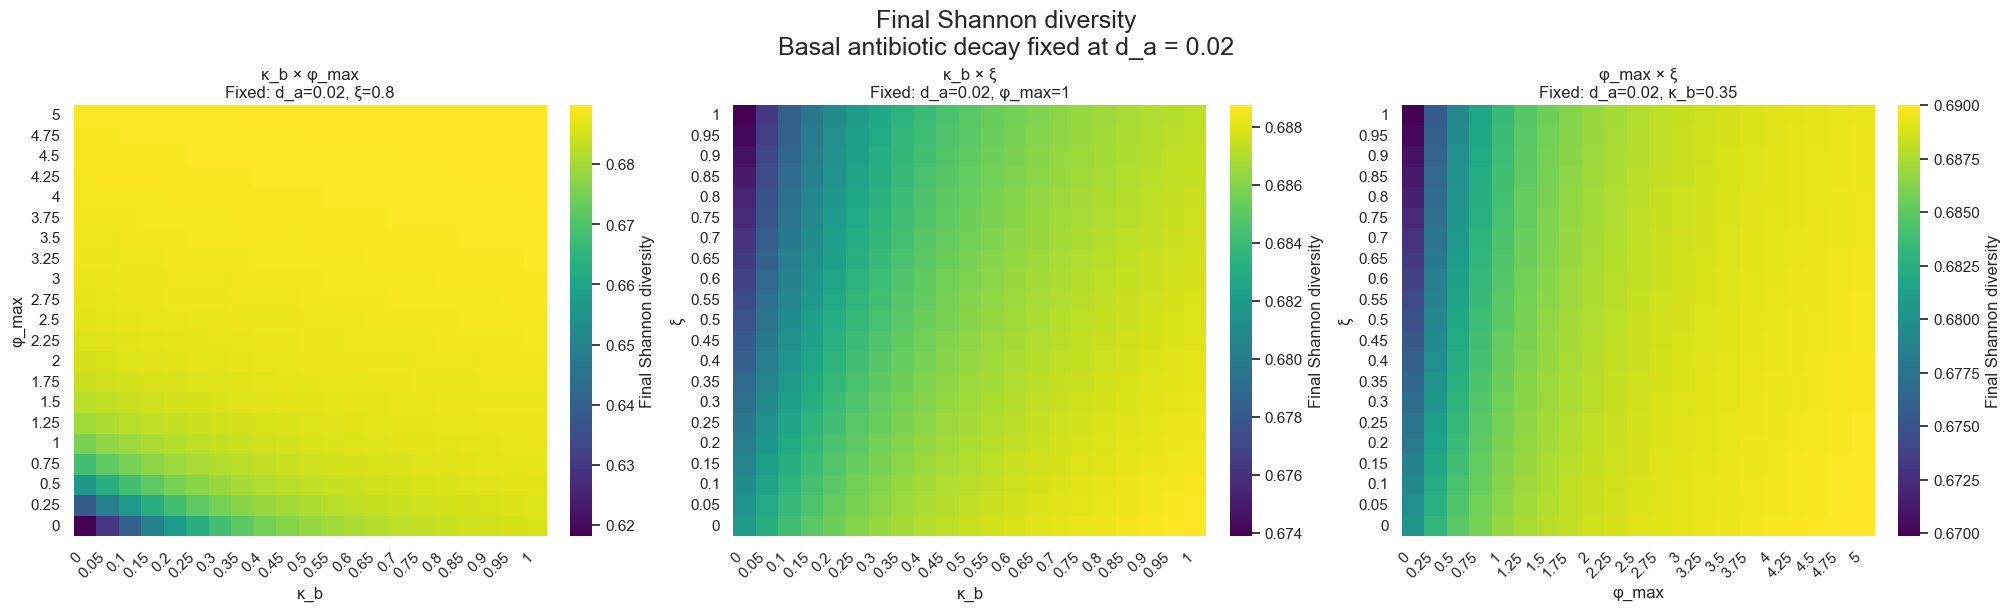

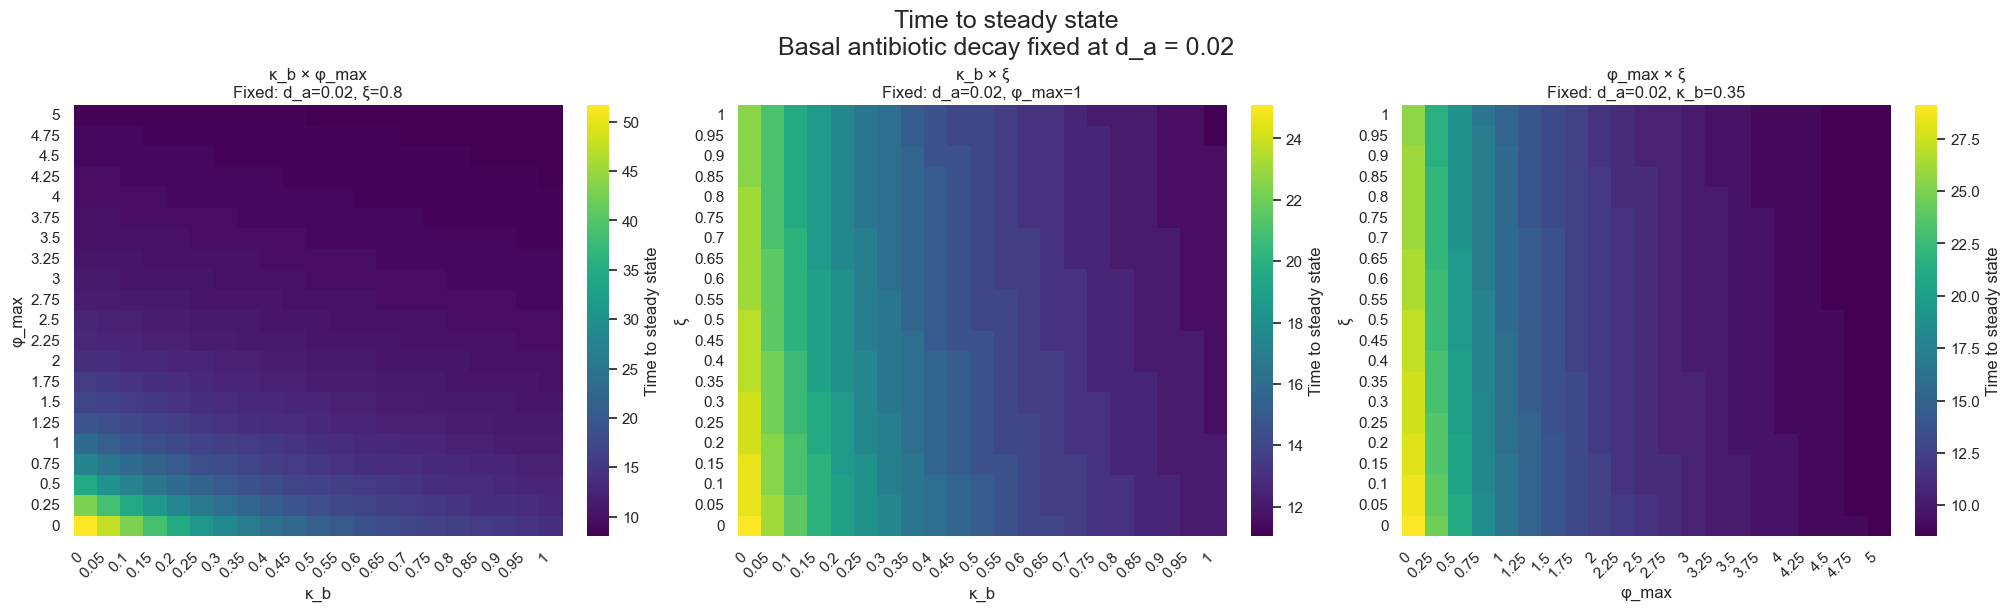

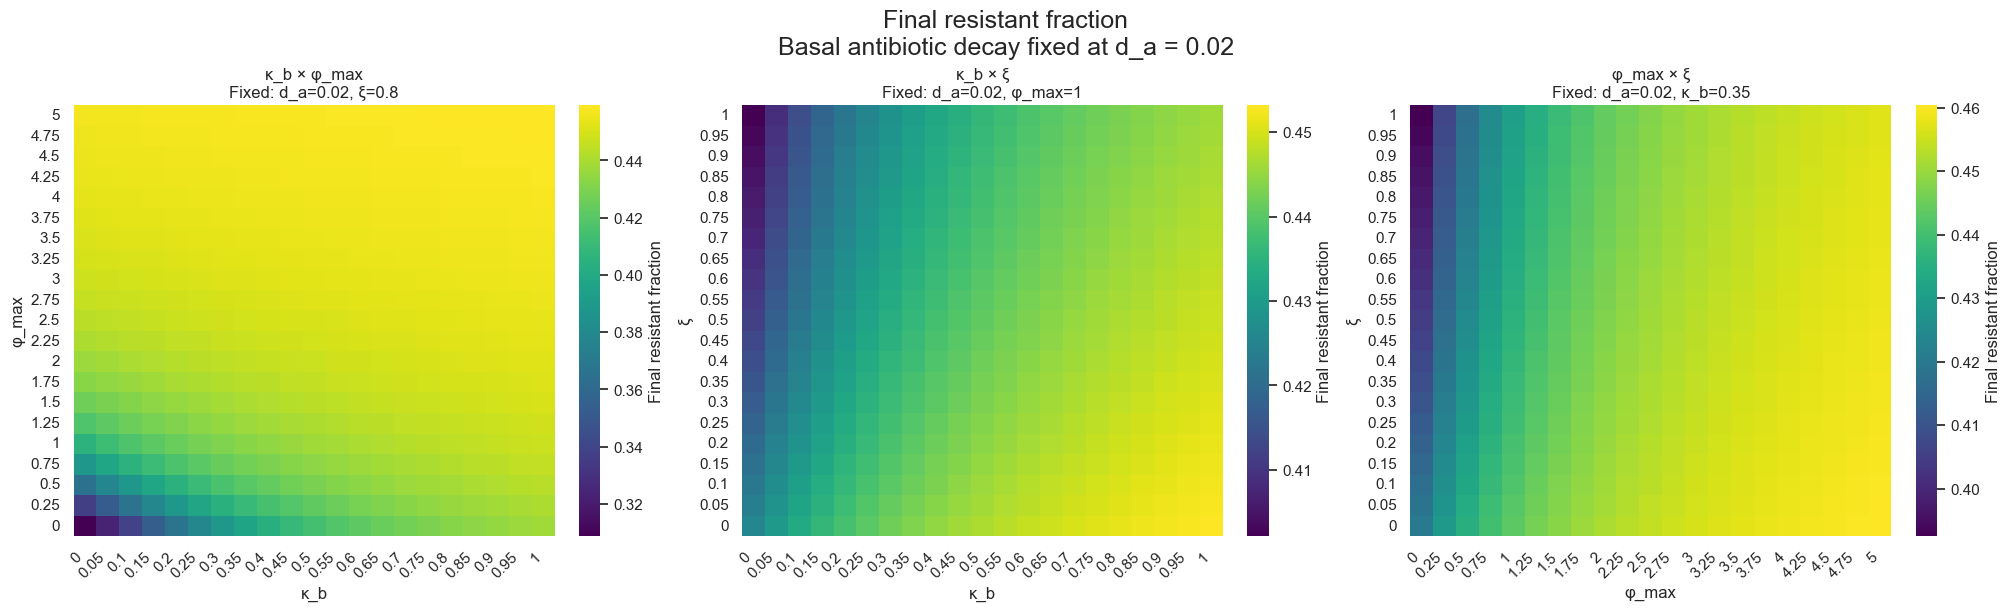

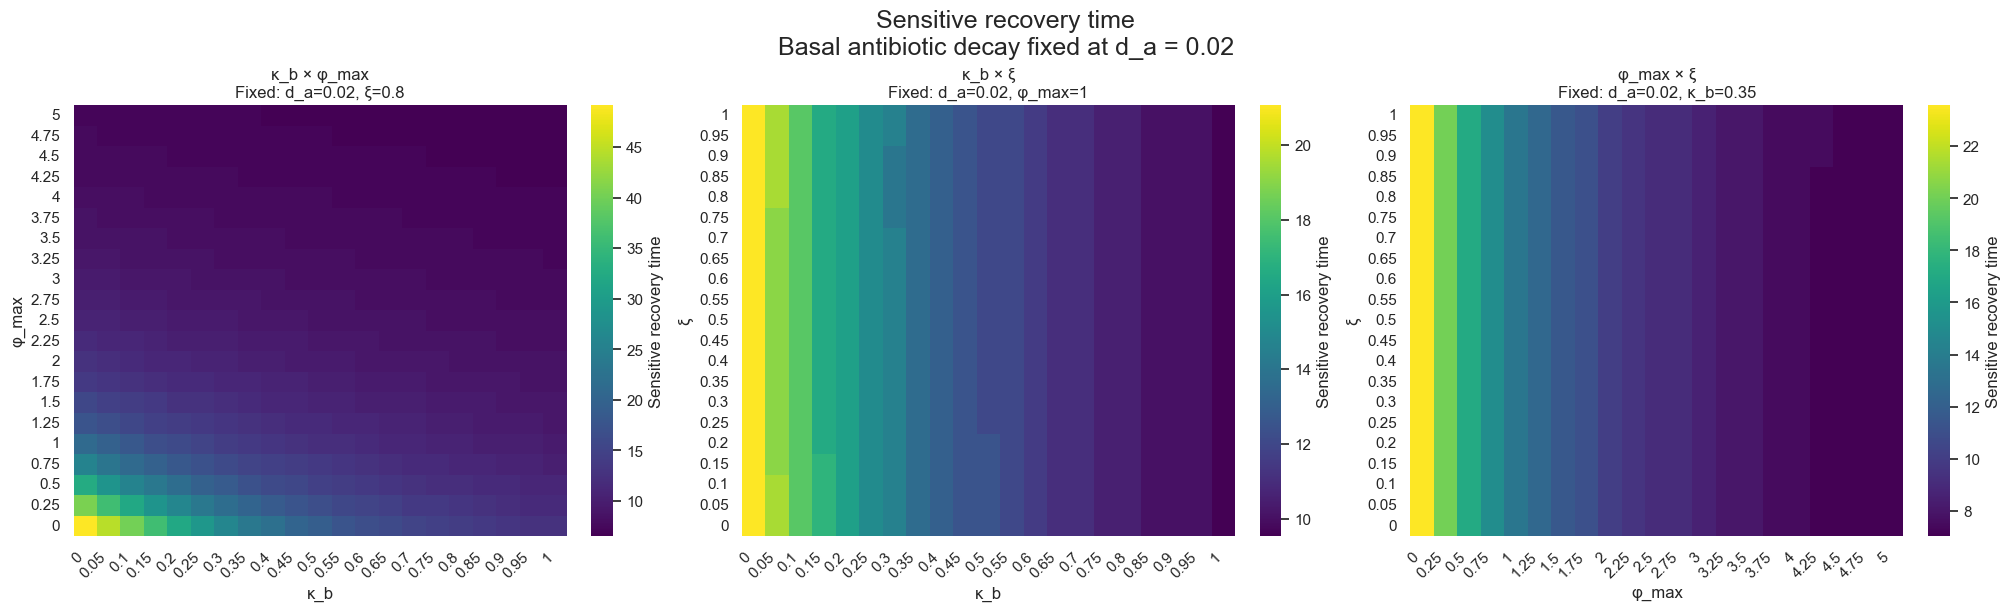

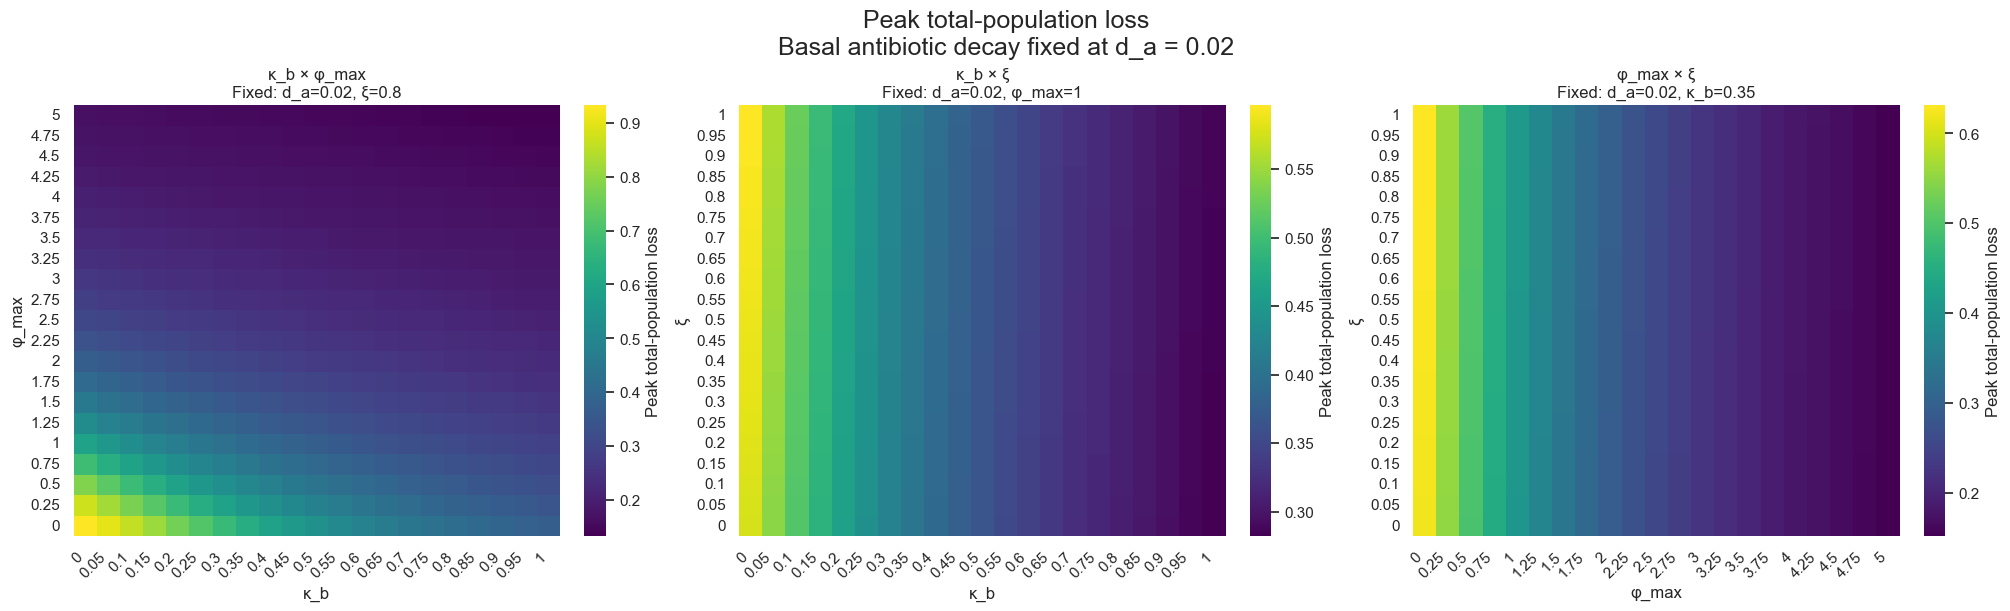

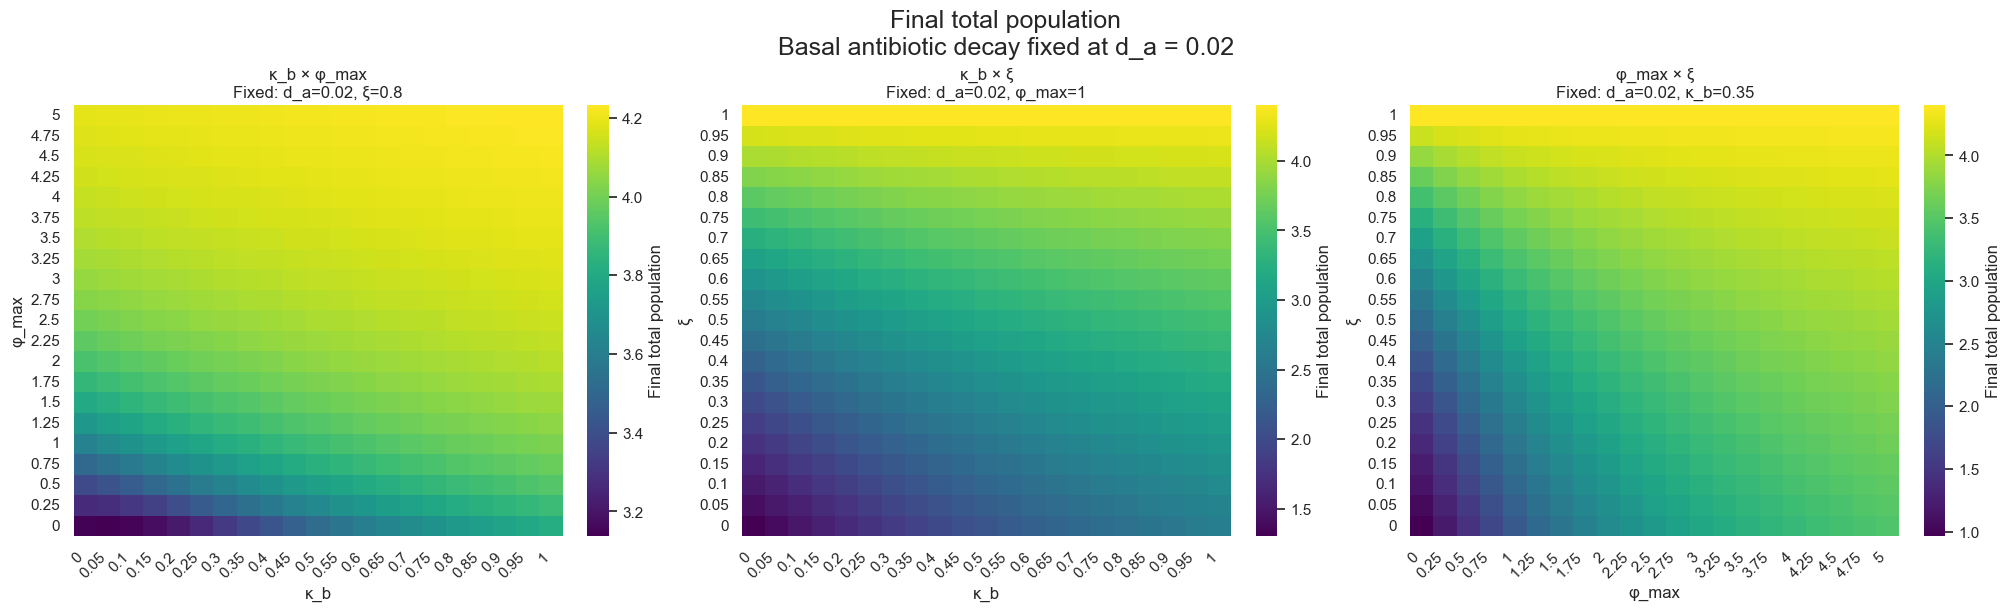

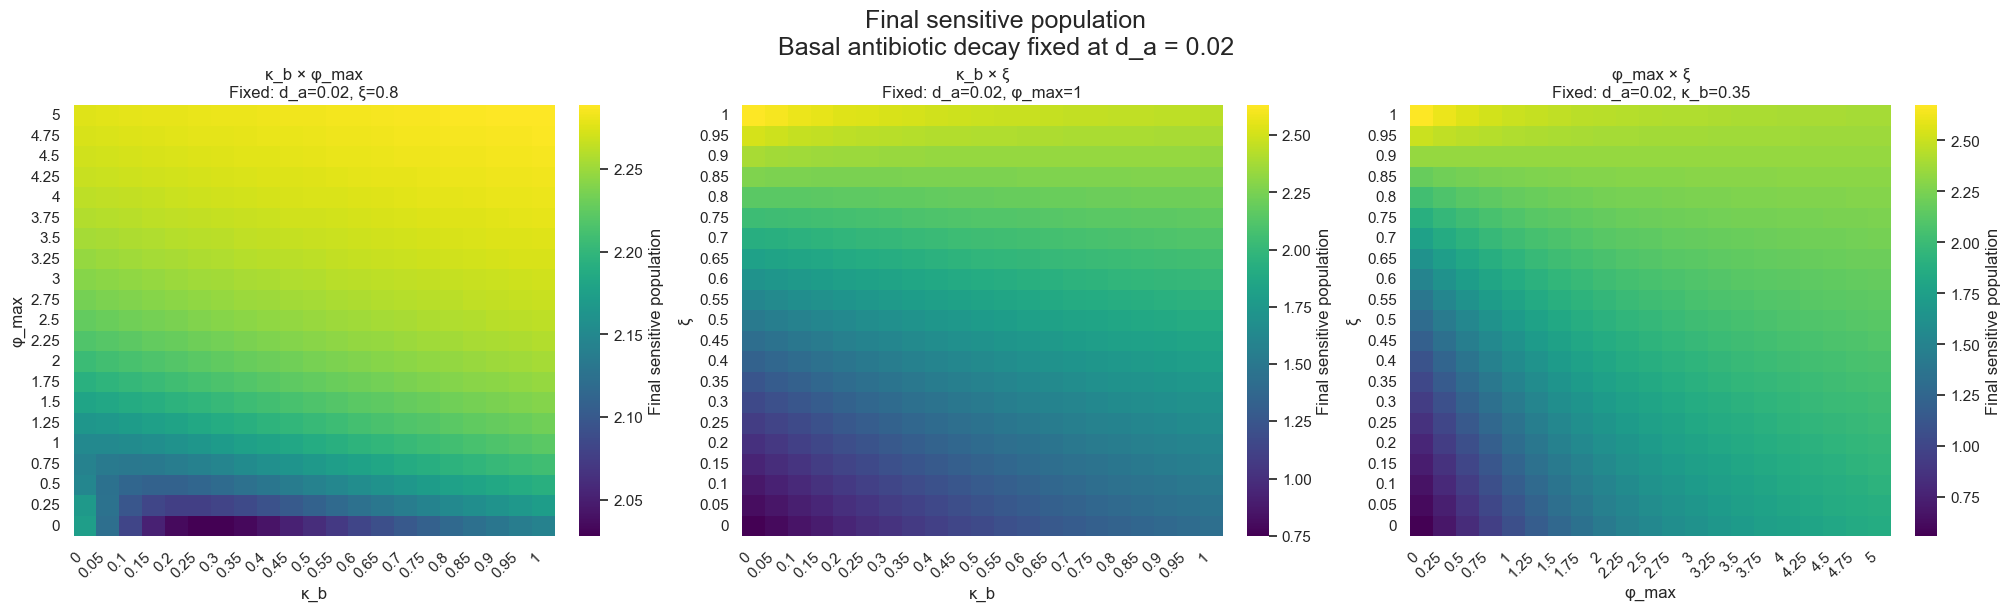

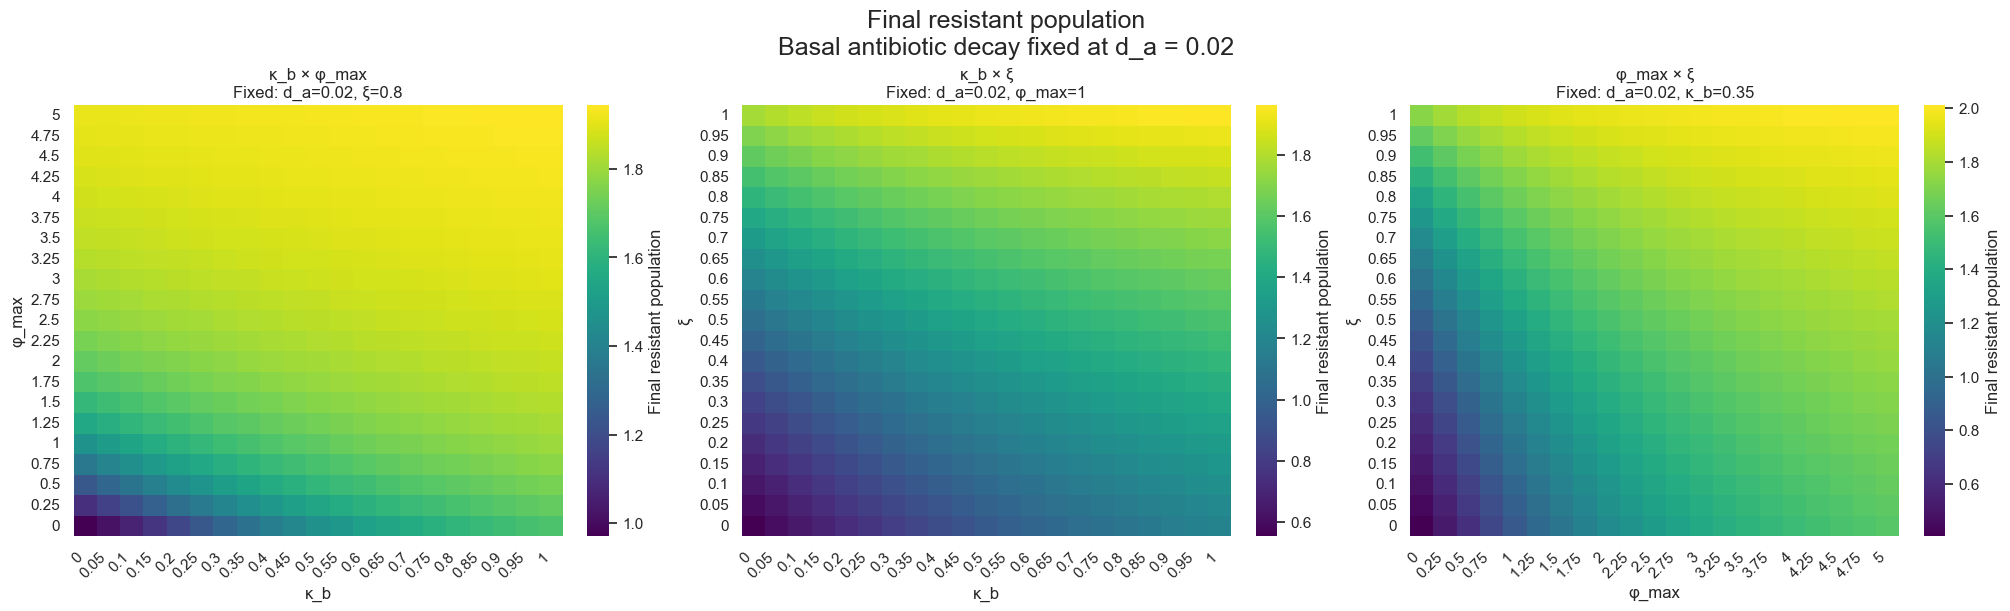

In [20]:
outcomes_to_plot = [
    "diversity_final",
    "t_steady_state",
    "f_R_final",
    "t_recovery_S",
    "peak_loss_total",
    "total_final",
    "ns_final",
    "nr_final"
]

for outcome in outcomes_to_plot:
    plot_all_parameter_pairs(outcome)
    plt.show()

## Nonconvergence: where it occurs and what it means

First, map whether a parameter combination converged. Then map the steady-state time and the final population size. A nonconverged point with near-zero populations suggests collapse; a nonconverged point with substantial populations suggests slow dynamics or a strict detector.

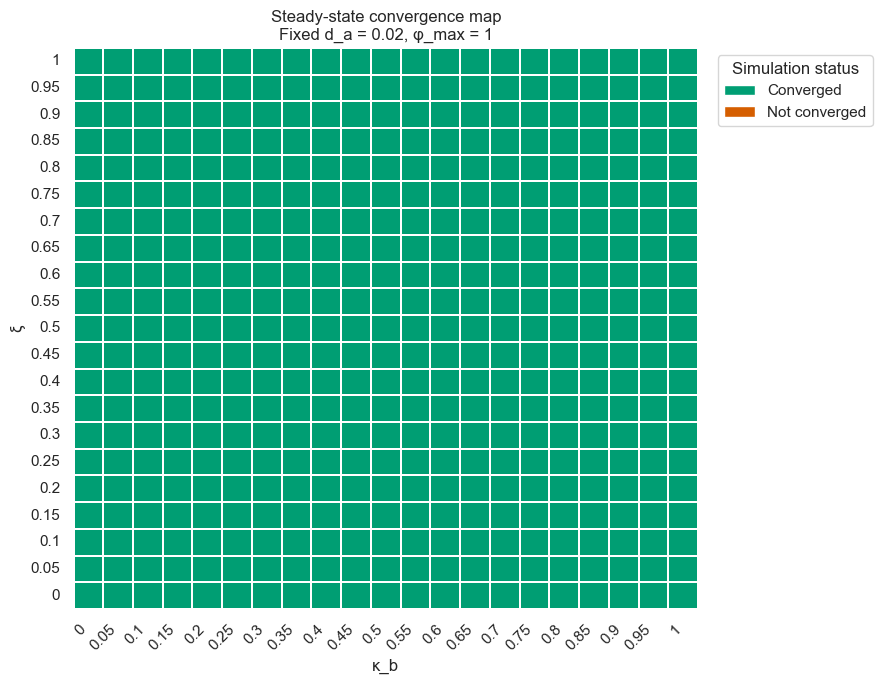

In [10]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# Hold d_a and phi_max at baseline
sub = df.copy()

for p in ["d_a", "phi_max"]:
    sub = sub[np.isclose(sub[p], nearest_value(p))]

table = (
    sub.pivot(
        index="xi",
        columns="kappa_b",
        values="nonconverged"
    )
    .sort_index(ascending=False)
)

# Convert Boolean values to 0/1
binary_table = table.astype(int)

fig, ax = plt.subplots(figsize=(9, 7))

colors = ["#009E73", "#D55E00"]  # green = converged, red = not converged
cmap = ListedColormap(colors)
norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

sns.heatmap(
    binary_table,
    ax=ax,
    cmap=cmap,
    norm=norm,
    cbar=False,
    linewidths=0.3,
    linecolor="white"
)

# Explicitly set tick positions to avoid the 11-versus-21 error
ax.set_xticks(np.arange(len(table.columns)) + 0.5)
ax.set_yticks(np.arange(len(table.index)) + 0.5)

ax.set_xticklabels(
    [f"{float(v):g}" for v in table.columns],
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    [f"{float(v):g}" for v in table.index],
    rotation=0
)

ax.set_xlabel("κ_b")
ax.set_ylabel("ξ")

ax.set_title(
    "Steady-state convergence map\n"
    "Fixed d_a = {:.3g}, φ_max = {:.3g}".format(
        nearest_value("d_a"),
        nearest_value("phi_max")
    )
)

legend_handles = [
    Patch(facecolor="#009E73", label="Converged"),
    Patch(facecolor="#D55E00", label="Not converged")
]

ax.legend(
    handles=legend_handles,
    title="Simulation status",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()
plt.show()

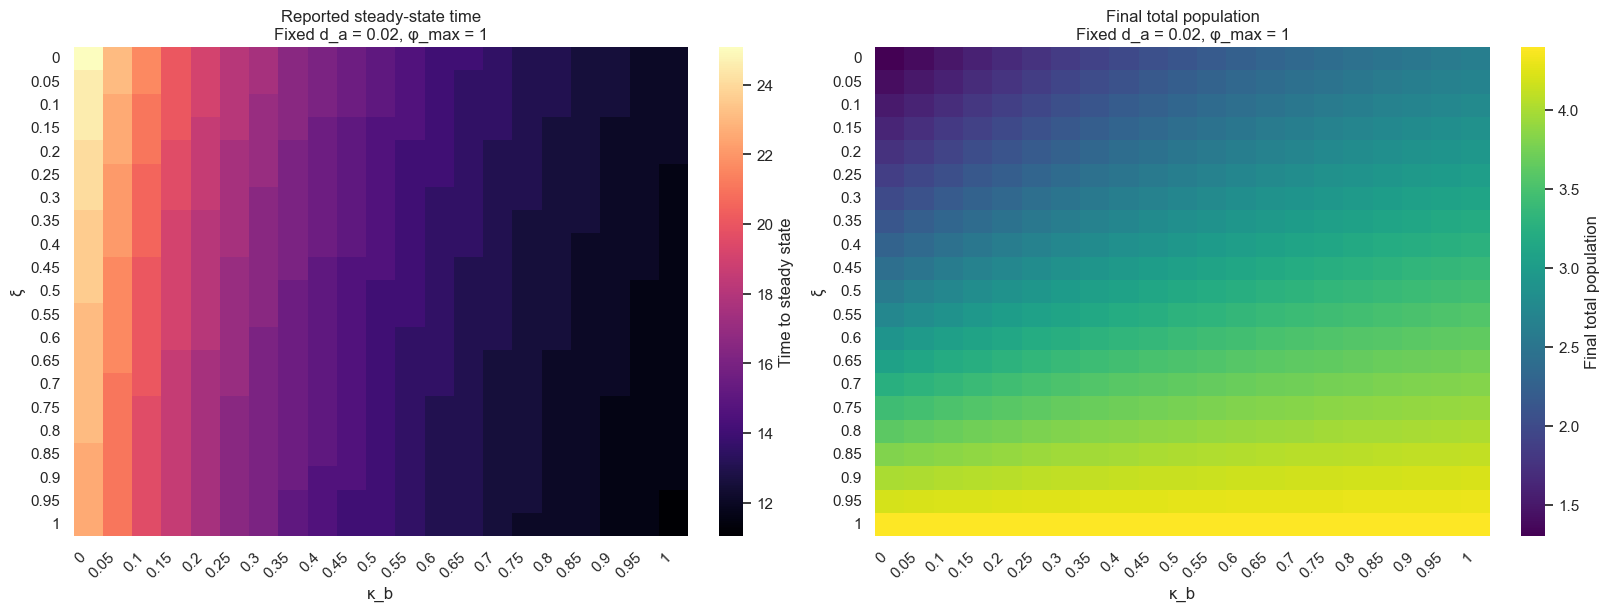

In [15]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6),
    constrained_layout=True
)

for ax, outcome, title, cmap in zip(
    axes,
    ["t_steady_state", "total_final"],
    ["Reported steady-state time", "Final total population"],
    ["magma", "viridis"]
):
    table, used = sliced_table(
        outcome,
        x="kappa_b",
        y="xi"
    )

    sns.heatmap(
        table,
        ax=ax,
        cmap=cmap,
        linewidths=0,
        linecolor=None,
            "label": OUTCOME_LABELS[outcome]
        
    )

    ax.set_xticks(np.arange(len(table.columns)) + 0.5)
    ax.set_yticks(np.arange(len(table.index)) + 0.5)

    ax.set_xticklabels(
        [f"{float(v):g}" for v in table.columns],
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(
        [f"{float(v):g}" for v in table.index],
        rotation=0
    )

    ax.set_xlabel("κ_b")
    ax.set_ylabel("ξ")

    ax.set_title(
        f"{title}\n"
        f"Fixed d_a = {nearest_value('d_a'):g}, "
        f"φ_max = {nearest_value('phi_max'):g}"
    )

plt.show()

### Nonconvergence diagnostics by category

nonconv_reason
converged                                             194019
near-zero population                                     282
substantial population; slow or strict convergence       180
Name: count, dtype: int64


sensitive_survives,False,True
nonconv_reason,,
converged,5538,188481
near-zero population,282,0
substantial population; slow or strict convergence,153,27


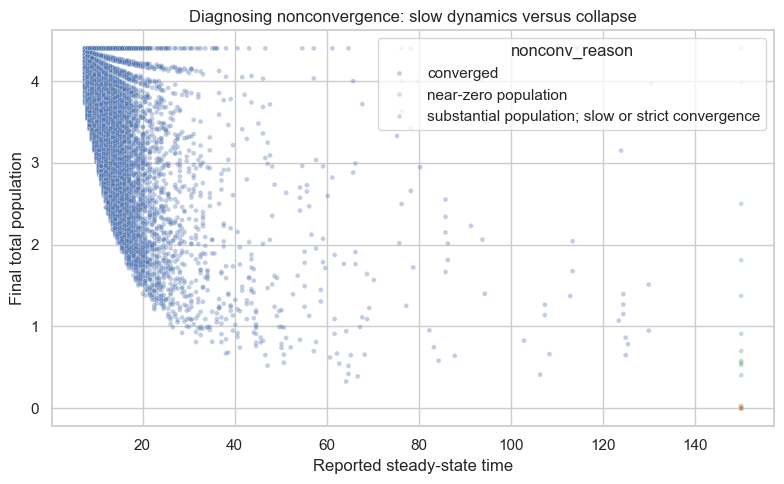

In [5]:
df['nonconv_reason'] = np.select([df['nonconverged'] & (df['total_final'] < 1e-6), df['nonconverged'] & (df['total_final'] >= 1e-6)], ['near-zero population','substantial population; slow or strict convergence'], default='converged')
print(df['nonconv_reason'].value_counts())
reason_counts = pd.crosstab(df['nonconv_reason'],df['sensitive_survives'])
display(reason_counts)

fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=df.sample(min(30000,len(df)),random_state=1), x='t_steady_state', y='total_final', hue='nonconv_reason', alpha=.35, s=12, ax=ax)
ax.set_xlabel('Reported steady-state time')
ax.set_ylabel('Final total population')
ax.set_title('Diagnosing nonconvergence: slow dynamics versus collapse')
plt.tight_layout(); plt.show()

## Representative time-course simulations

These examples compare antibiotic concentration, sensitive population, and resistant population on the same time axis. The baseline trajectory is shown alongside low and high values of one focal parameter while the other three Person 4 parameters stay at baseline.

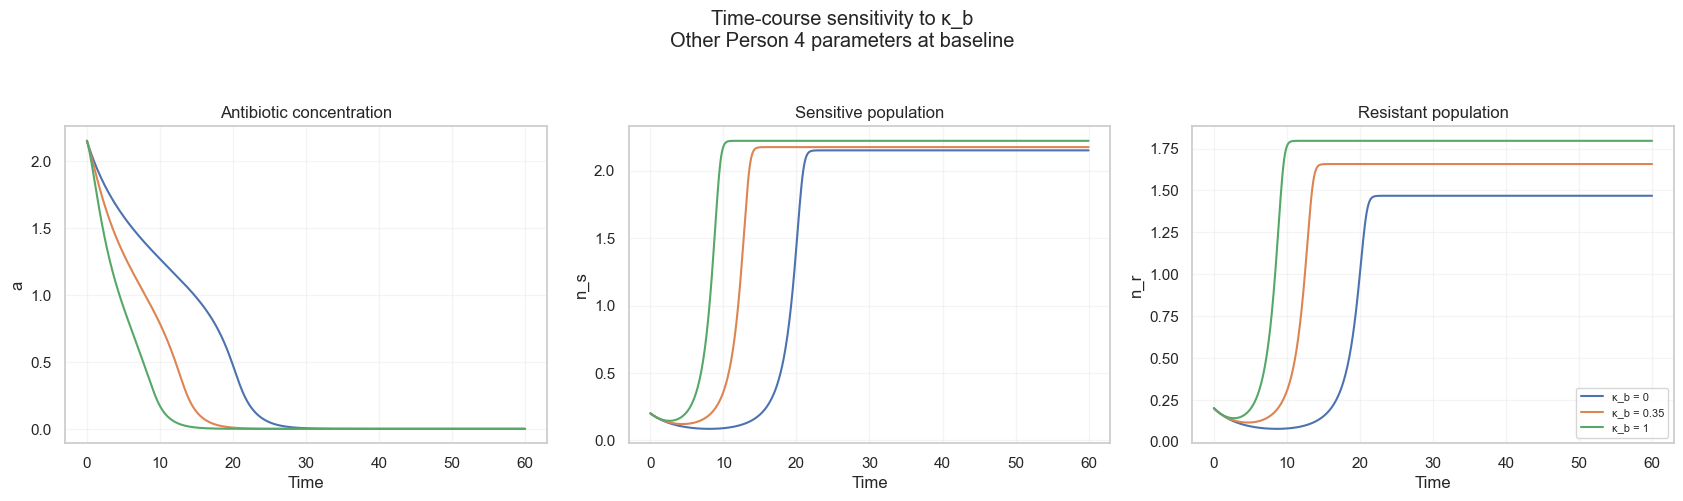

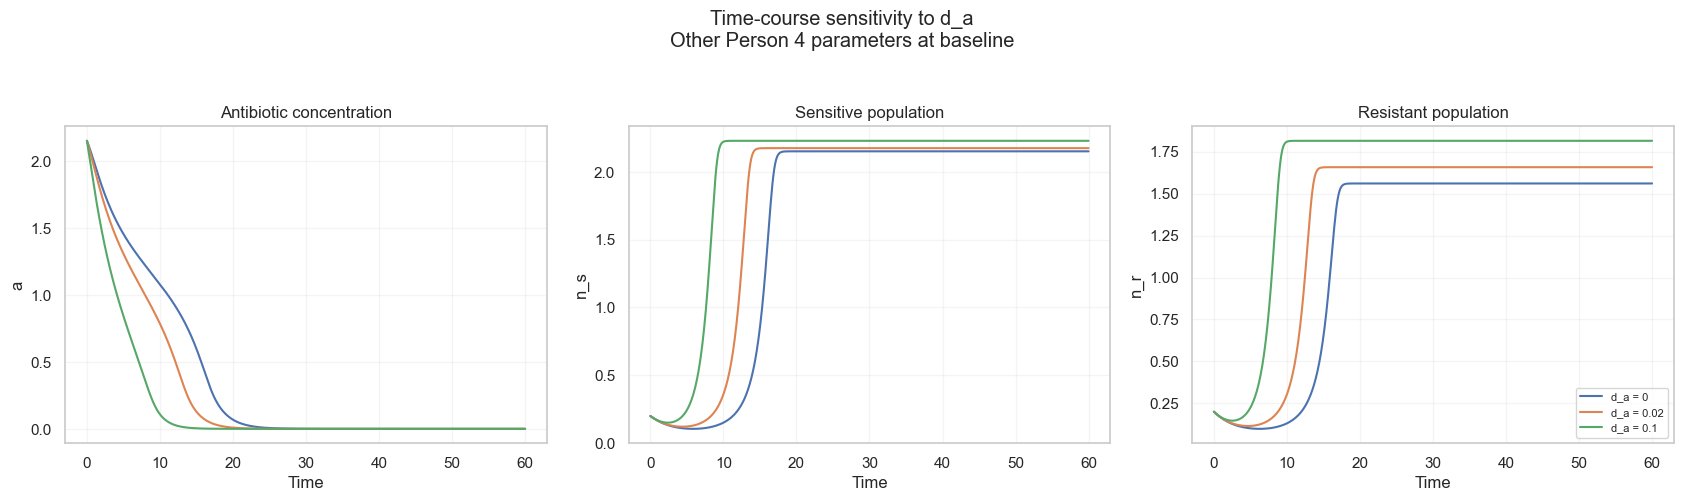

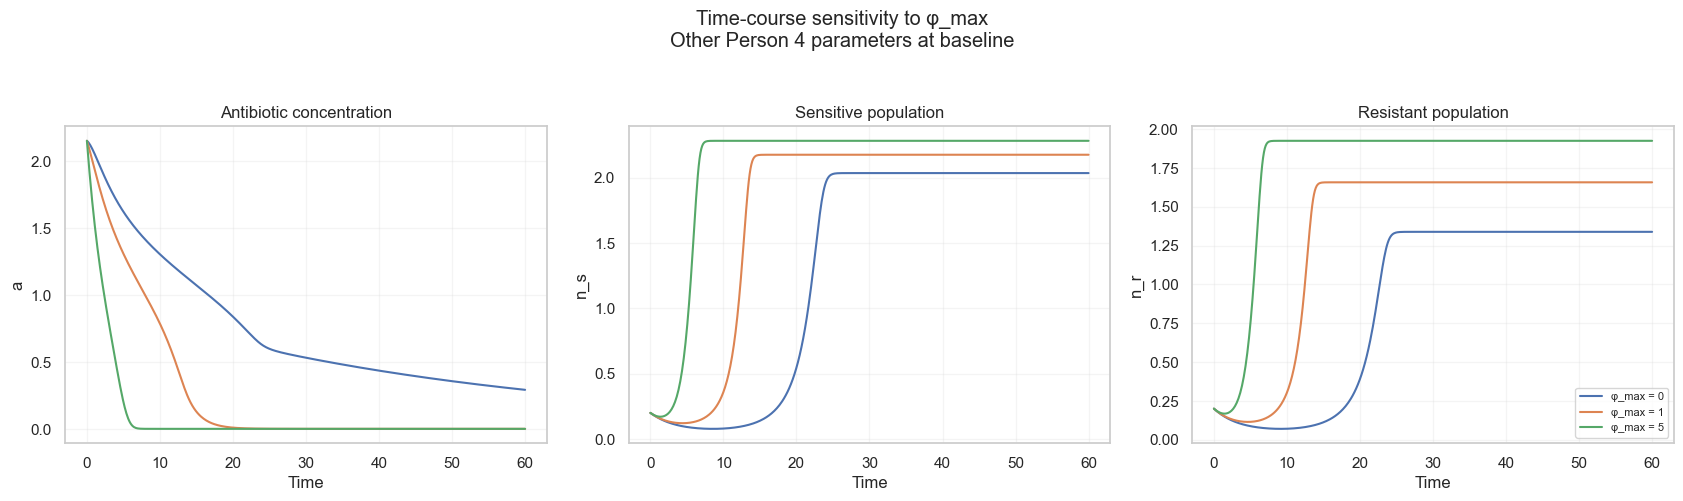

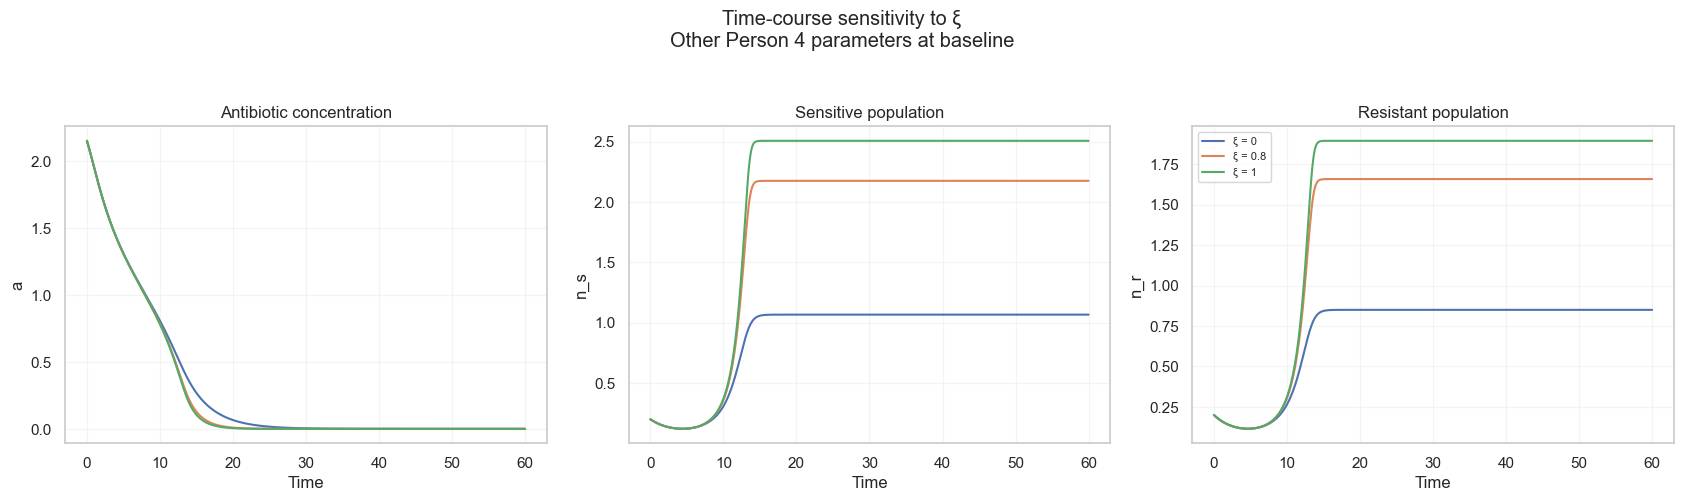

In [6]:
def representative_values(parameter):
    values = np.sort(df[parameter].unique())
    return [values[0], nearest_value(parameter), values[-1]]

def plot_timecourses(parameter, t_end=60):
    values = representative_values(parameter)
    fig, axes = plt.subplots(1,3,figsize=(17,4.8),sharex=True)
    for value in values:
        p = replace(DEFAULT_PARAMS, **{parameter:float(value)})
        sol = simulate_logspace(p,a0=2.15,i_dose=10,t_span=(0,t_end),n_points=500)
        label = f'{LABELS[parameter]} = {value:g}'
        axes[0].plot(sol.t,sol.a,label=label)
        axes[1].plot(sol.t,sol.ns,label=label)
        axes[2].plot(sol.t,sol.nr,label=label)
    for ax,title,ylabel in zip(axes,['Antibiotic concentration','Sensitive population','Resistant population'],['a','n_s','n_r']):
        ax.set_title(title); ax.set_xlabel('Time'); ax.set_ylabel(ylabel); ax.grid(alpha=.2)
    axes[-1].legend(fontsize=8)
    fig.suptitle(f'Time-course sensitivity to {LABELS[parameter]}\nOther Person 4 parameters at baseline',y=1.04)
    plt.tight_layout(); return fig,axes

for parameter in PARAMS:
    plot_timecourses(parameter); plt.show()

## Direct comparison of baseline, fastest-recovery, and deepest-crash cases

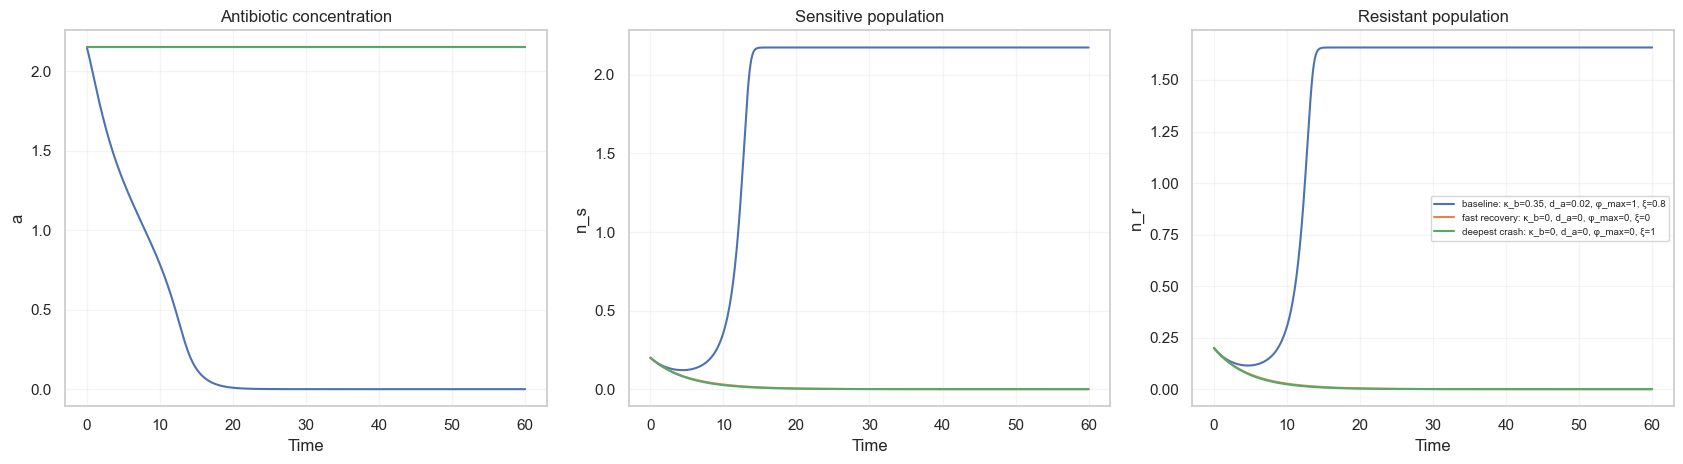

,kappa_b,d_a,phi_max,xi,t_recovery_S,t_steady_state,peak_loss_total,f_R_final,total_final
baseline,0.35,0.02,1.0,0.8,13.545151,15.551839,0.410143,0.432555,3.832299
fast recovery,0.0,0.0,0.0,0.0,0.0,150.0,1.0,0.224561,0.0
deepest crash,0.0,0.0,0.0,1.0,0.0,150.0,1.0,0.196754,0.0


In [7]:
# Select representative rows from the CSV and rerun their trajectories for visualization.
baseline_row = df.iloc[((df[PARAMS]-pd.Series(BASELINE)).abs().sum(axis=1)).argmin()]
fast_row = df.loc[df['t_recovery_S'].idxmin()]
deep_row = df.loc[df['peak_loss_total'].idxmax()]
cases = {'baseline':baseline_row,'fast recovery':fast_row,'deepest crash':deep_row}

fig, axes = plt.subplots(1,3,figsize=(17,4.8),sharex=True)
for name,row in cases.items():
    p = replace(DEFAULT_PARAMS, **{k:float(row[k]) for k in PARAMS})
    sol = simulate_logspace(p,a0=2.15,i_dose=10,t_span=(0,60),n_points=500)
    label = name + ': ' + ', '.join(f'{LABELS[k]}={row[k]:g}' for k in PARAMS)
    axes[0].plot(sol.t,sol.a,label=label); axes[1].plot(sol.t,sol.ns,label=label); axes[2].plot(sol.t,sol.nr,label=label)
for ax,title,ylabel in zip(axes,['Antibiotic concentration','Sensitive population','Resistant population'],['a','n_s','n_r']):
    ax.set_title(title); ax.set_xlabel('Time'); ax.set_ylabel(ylabel); ax.grid(alpha=.2)
axes[-1].legend(fontsize=7)
plt.tight_layout(); plt.show()
display(pd.DataFrame(cases).T[PARAMS+['t_recovery_S','t_steady_state','peak_loss_total','f_R_final','total_final']])

## Interpretation reminders

- Interpret final resistant fraction together with final total population. A high fraction is not necessarily healthy recovery if both populations are nearly extinct.
- Use peak loss for acute bottleneck risk, recovery time for rebound speed, and steady-state time for whole-system settling.
- Treat nonconverged cases as not converged within the observation window unless longer simulations show otherwise.
- If axis values display floating-point artifacts, the plotting labels are rounded here without changing the underlying parameter values.